# DSF-Net: Spectral-Spatial Detection of AI-Generated Images

**Deep Learning - Final Project**

**Author:** Nihat Garibli

---

## Abstract

Modern diffusion models synthesise photographs that humans cannot reliably distinguish from real
ones. Detecting them is a *forensic* problem rather than a semantic one: a fake photo of a dog and a
real photo of a dog contain the same dog, so the object category carries no signal. What does carry
signal is the **generator fingerprint**: periodic, high-frequency artefacts left behind by the
upsampling stack inside the generator. These artefacts are faint in pixel space but structurally
obvious in the 2D Fourier magnitude spectrum.

This project designs **DSF-Net (Dual-Stream Forensic Network)**, a custom architecture built around
that observation. It processes each image through two parallel streams, a *spatial* stream fronted by
a constrained high-pass filter that suppresses image content, and a *frequency* stream that operates
directly on the log-magnitude spectrum plus its radial profile, and fuses them with a **learned
per-dimension gate** *intended* to decide, per image, how much to trust each view of the evidence.

We train on **CIFAKE** (60k real CIFAR-10 photographs vs 60k Stable Diffusion v1.4 images at 32x32),
compare against three baselines (a classical spectral classifier, the CIFAKE paper's own CNN, and a
fine-tuned ResNet-18), run a seven-way ablation, and stress-test every model under JPEG compression,
blur, noise and rescaling. DSF-Net reaches **95.71% test accuracy** and **0.9910 ROC-AUC** with 848k
parameters, **2.73 points above the published CIFAKE reference (92.98%)**, at 13.2x fewer parameters
than a fine-tuned ResNet-18, which still beats it by 2.10 points.

**The architectural hypotheses largely did not survive testing, and this notebook reports that
outcome rather than working around it.** The entire study was executed **twice, end to end**, which
lets every finding be labelled as replicated or not. Three replicated: the frequency stream alone is
far weaker than the spatial stream (-4.3 points), removing the constrained forensic front-end
*improves* accuracy (+1.0 points), and heavy conventional augmentation *helps* rather than harms
(+0.9 points), the opposite of the design argument. The central claim, that gated fusion beats plain
concatenation, **did not replicate**: the two runs disagree in sign (+0.02 pp and -0.49 pp). The gate
also failed its behavioural test, moving by less than 0.006 across the full JPEG quality range, and
Section 18.3 shows it is structurally non-identifiable, so it could never have been read as a trust
signal as built. The one intervention that did work is JPEG augmentation: +4.82 points under heavy
compression at no cost on clean images.

---

## Table of contents

1. Problem statement and related work
2. Environment setup
3. Data acquisition
4. Exploratory data analysis and the spectral hypothesis
5. Preprocessing, datasets and dataloaders
6. Metrics and the shared training harness
7. Baseline 1, classical radial-spectrum classifier
8. Baseline 2, CIFAKE reference CNN
9. Baseline 3, ResNet-18 transfer learning
10. DSF-Net, the custom architecture
11. Training the neural models
12. Hyperparameter tuning
13. Test-set evaluation
14. Ablation study
15. Robustness study
16. Explainability
17. Error analysis
18. Discussion
19. Conclusion and references

## 1. Problem statement and related work

### 1.1 The problem

Given an RGB image, decide whether it was **captured by a camera** (`REAL`) or **synthesised by a
generative model** (`FAKE`). We treat `FAKE` as the positive class, because in every realistic
deployment, content moderation, evidence verification, keeping synthetic images out of a training
corpus, the cost of interest is *missing a fake*.

### 1.2 Why it is not ordinary image classification

Three properties make this task structurally different from CIFAR-10-style classification, and each
one drives a design decision later in this notebook:

| Property | Consequence for the model |
|---|---|
| Semantic content is a **nuisance variable**, identical across classes | Suppress content explicitly instead of learning to ignore it |
| The signal lives in **high spatial frequencies**, at very low amplitude | Give the network a frequency-domain view directly, do not hope it infers one |
| The signal is **fragile**: JPEG, blur or resizing erase it | Robustness must be measured, not assumed; the model needs a fallback |

The third row also inverts a habit: in normal vision work, aggressive augmentation is free accuracy.
Here, colour jitter and blur act directly on the evidence the model depends on, so the expectation is
that they should cost accuracy. Section 14 (ablation 7) measures what heavy augmentation actually does,
and Section 15 measures what these transforms do when they arrive at test time instead. The first of
those two measurements comes out the opposite way round; it is reported in Section 18.1.

### 1.3 Related work

* **Bird & Lotfi (2024), "CIFAKE"**: introduces the dataset used here and reports **92.98%** accuracy
  with a small CNN plus Grad-CAM explanations. This is our reference number; Section 12 compares
  against it on the identical split.
* **Wang et al. (2020), "CNN-generated images are surprisingly easy to spot... for now"**: shows that
  detectors trained on one generator transfer poorly to others, and that JPEG/blur augmentation during
  training is what buys robustness. Section 15 reproduces both effects at small scale.
* **Frank et al. (2020), "Leveraging Frequency Analysis for Deep Fake Image Recognition"**: documents
  the grid artefact in the DCT/Fourier spectrum of GAN images that motivates our frequency stream.
* **Bayar & Stamm (2018)**: the *constrained convolution* layer from image forensics, which forces the
  first layer to compute a prediction residual. We adopt it as the front-end of the spatial stream.
* **Zhu et al. (2023), "GenImage"**: a million-scale benchmark defining the cross-generator and
  degraded-image evaluation protocols that Section 15 follows in miniature.

### 1.4 Contribution of this project

1. A custom dual-stream architecture with an inspectable gated fusion: not a fine-tuned backbone.
2. A seven-way ablation that isolates the contribution of *each* design decision, judged against a
   **measured noise floor** rather than against zero.
3. **A full two-run replication of the entire study**, which separates findings that hold from
   findings that were artefacts of a single run, including this project's own central hypothesis.
4. Identification of a structural flaw in the gate design that explains its failure, with a concrete
   correction proposed for future work (Section 18.3).
5. A ten-condition robustness study and a working mitigation (JPEG augmentation).
6. An honest evaluation: the refuted hypotheses are reported as prominently as the numbers that
   worked, including the generalisation gap.

## 2. Environment setup

The notebook runs unchanged on **Google Colab (T4 GPU)** and on a **local CUDA machine**. It detects
which it is on and adjusts paths, installs and worker counts accordingly.

On Colab: set `Runtime -> Change runtime type -> T4 GPU` before running.

In [1]:
# Detect environment and install anything the platform is missing.
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
print(f"Running on Colab: {IN_COLAB}")

if IN_COLAB:
    # Colab ships torch/sklearn/matplotlib; `datasets` is the only reliable gap.
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "datasets>=2.18", "seaborn"],
        check=True,
    )

Running on Colab: False


In [2]:
# @smoke
# Standard library
import io
import math
import os
import random
import sys
import time
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

# Third party
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# Windows terminals still default to a legacy code page (cp1252), which cannot encode the
# em-dashes and Greek letters this notebook prints. Without this, a perfectly correct run
# dies with a UnicodeEncodeError halfway through. Jupyter and Colab are already UTF-8, so
# this is a no-op there.
for _stream in (sys.stdout, sys.stderr):
    try:
        _stream.reconfigure(encoding="utf-8", errors="replace")
    except (AttributeError, ValueError):
        pass

# Render figures inside the notebook when running under a Jupyter/Colab kernel, and fall
# back to a file-only backend when this file is executed as a plain script. Written as a
# guarded call rather than a bare `%matplotlib inline` magic so both paths work.
try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

print(f"torch      {torch.__version__}")
print(f"numpy      {np.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU        {torch.cuda.get_device_name(0)}")

torch      2.13.0+cu132
numpy      2.4.4
CUDA available: True
GPU        NVIDIA GeForce RTX 5070 Laptop GPU


### 2.1 Reproducibility

Every experiment in this notebook is seeded. `seed_everything` is called before each training run so
that model A and model B see the same batch order and the same augmentation draws, otherwise the
comparison table in Section 12 would be measuring noise as much as architecture.

We deliberately leave `cudnn.benchmark = True` on: bit-exact determinism would cost roughly 20-30%
throughput. That means two runs of the *same* configuration will not agree exactly. Rather than
ignore this, Section 14.1 measures it: the tuned model is trained twice under different names, and
the gap between those two runs defines a **noise floor** below which no difference in the ablation
table can be believed.

In [3]:
# @smoke
def seed_everything(seed: int = 42) -> None:
    """Seed Python, NumPy and PyTorch RNGs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"
torch.backends.cudnn.benchmark = True

print(f"Device: {DEVICE} | mixed precision: {AMP_ENABLED}")

Device: cuda | mixed precision: True


### 2.2 Quick-run switch

`QUICK_RUN = True` executes the entire notebook end to end in a few minutes on a small subsample with
2-epoch training runs. Nothing is skipped, every figure, every ablation and every robustness
condition still runs, but the numbers are meaningless.

Use it to verify the whole pipeline works *before* committing to the full run, and after any edit.
Set it back to `False` for the results that go into the report.

In [4]:
# @smoke
QUICK_RUN = False

# Sample sizes used by the analysis sections, scaled down in quick mode.
EDA_SAMPLE = 2000 if QUICK_RUN else 20000       # images used for the spectral EDA
ROBUST_N = 1000 if QUICK_RUN else 10000         # test images per degradation condition
FINGERPRINT_N = 800 if QUICK_RUN else 3000      # images per fingerprint difference map
TSNE_N = 800 if QUICK_RUN else 2500             # embeddings fed to t-SNE

if QUICK_RUN:
    print("QUICK_RUN is ON — results are for pipeline verification only, not for the report.")

### 2.2 Project paths

On Colab we mount Google Drive and write every checkpoint, cached array and figure there. This matters
for a multi-day project: a Colab session can be reclaimed at any time, and without Drive-backed
checkpoints every timeout would mean retraining from scratch.

In [5]:
if IN_COLAB:
    from google.colab import drive  # type: ignore[import-not-found]

    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/dl_final_aigid")
else:
    # Local run: the notebook lives in <project>/notebooks/
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
CKPT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"

for d in (DATA_DIR, CKPT_DIR, RESULTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")


def save_fig(name: str) -> None:
    """Save the current matplotlib figure into results/figures under a stable name."""
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path)
    print(f"  saved -> {path.relative_to(PROJECT_ROOT)}")

Project root: C:\Users\Nihat\Desktop\deep learning final assig


## 3. Data acquisition

### 3.1 The CIFAKE dataset

| | |
|---|---|
| **Real images** | 60,000 photographs from CIFAR-10 |
| **Fake images** | 60,000 images generated with Stable Diffusion v1.4, prompted to match the CIFAR-10 classes |
| **Resolution** | 32x32 RGB |
| **Canonical split** | 100,000 train / 20,000 test, balanced |
| **Licence** | CC BY-NC 4.0 (Bird & Lotfi, 2024) |

The low resolution is a deliberate feature of the benchmark, not a shortcut. With only 1,024 pixels per
image there is very little fingerprint to find, which makes the task *harder* than at 256x256, and it
keeps the whole study, including 15+ training runs, inside a single Colab session budget.

We pull it from the Hugging Face Hub, which needs no API token. A Kaggle fallback is included below in
case the mirror ever moves.

In [6]:
from datasets import load_dataset

HF_DATASET_ID = "dragonintelligence/CIFAKE-image-dataset"

raw = load_dataset(HF_DATASET_ID)
print(raw)

label_names = raw["train"].features["label"].names
print(f"\nClassLabel names (index order): {label_names}")

# Never assume the index order. Derive it and assert it, so a silently reordered
# mirror produces a loud failure rather than an inverted model.
FAKE_INDEX = label_names.index("FAKE")
REAL_INDEX = label_names.index("REAL")
assert {FAKE_INDEX, REAL_INDEX} == {0, 1}, "Expected exactly two classes"
print(f"FAKE -> raw index {FAKE_INDEX} | REAL -> raw index {REAL_INDEX}")
print("Our convention: y = 1 means FAKE (positive class), y = 0 means REAL")

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 20000
    })
})

ClassLabel names (index order): ['FAKE', 'REAL']
FAKE -> raw index 0 | REAL -> raw index 1
Our convention: y = 1 means FAKE (positive class), y = 0 means REAL


### 3.2 A property of the data worth knowing: the images are already JPEG

CIFAKE is distributed as JPEG files, not PNG. That matters more here than it would for ordinary
classification, and it cuts two ways.

**The risk.** If real and fake images had been encoded with different JPEG settings, a model could
reach high accuracy by reading the *encoder's* fingerprint instead of the *generator's*. That is a
label leak, and it would invalidate the entire study. So we check the quantisation tables directly
rather than assuming they match.

**The consequence.** Because both classes do share one encoder setting, the artefact we are detecting
is one that has *already survived* a round of JPEG compression. This makes the task harder than it
would be on lossless images, and it makes the result more practically relevant, a detector that only
worked on pristine PNGs would be useless. It also means the degradation study in Section 15 is
measuring *double* compression, which is precisely what an image re-shared online undergoes.

In [7]:
def jpeg_signature(pil_image) -> tuple:
    """Summarise a JPEG's quantisation tables. Identical tables mean identical encoder settings."""
    tables = getattr(pil_image, "quantization", None)
    if not tables:
        return ("not-jpeg",)
    return tuple(sum(tables[key]) for key in sorted(tables))


# NOTE: the published split is ordered by label - the first half is all FAKE, the second
# half all REAL. Sampling the first N images would therefore see only one class. Every
# subsample in this notebook is drawn at random or stratified for exactly this reason.
probe_idx = np.linspace(0, len(raw["train"]) - 1, 400).astype(int)

signatures = {0: set(), 1: set()}
formats = set()
for i in probe_idx:
    example = raw["train"][int(i)]
    formats.add(example["image"].format)
    signatures[1 if example["label"] == FAKE_INDEX else 0].add(jpeg_signature(example["image"]))

print(f"storage format(s) seen        : {formats}")
print(f"REAL quantisation signatures  : {signatures[0]}")
print(f"FAKE quantisation signatures  : {signatures[1]}")

assert signatures[0] == signatures[1], (
    "REAL and FAKE images were encoded with different JPEG settings. The compression itself would "
    "leak the label, and every accuracy number below would be measuring the wrong thing."
)
print()
print("Both classes share the same encoder settings, so JPEG encoding cannot leak the label.")
print("The fingerprint this project detects is therefore one that survives moderate JPEG")
print("compression — which is what makes it worth detecting at all.")

storage format(s) seen        : {'JPEG'}
REAL quantisation signatures  : {(1858, 2780)}
FAKE quantisation signatures  : {(1858, 2780)}

Both classes share the same encoder settings, so JPEG encoding cannot leak the label.
The fingerprint this project detects is therefore one that survives moderate JPEG
compression — which is what makes it worth detecting at all.


#### Kaggle fallback (only if the Hugging Face mirror is unavailable)

Uncomment, upload your `kaggle.json` when prompted, and re-run.

In [8]:
# if IN_COLAB:
#     from google.colab import files
#     files.upload()                                  # select kaggle.json
#     os.makedirs("/root/.kaggle", exist_ok=True)
#     os.replace("kaggle.json", "/root/.kaggle/kaggle.json")
#     os.chmod("/root/.kaggle/kaggle.json", 0o600)
#     subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)
#     subprocess.run(
#         ["kaggle", "datasets", "download", "-d",
#          "birdy654/cifake-real-and-ai-generated-synthetic-images",
#          "-p", str(DATA_DIR), "--unzip"],
#         check=True,
#     )
#     # The Kaggle version is a folder tree: train/{REAL,FAKE}, test/{REAL,FAKE}.
#     # Load it with torchvision.datasets.ImageFolder and skip the decode cell below.

### 3.3 Decoding to arrays, once

Iterating 120,000 PIL images takes a few minutes. We do it once and cache the result as `uint8` NumPy
arrays on Drive (~370 MB total). Every later session loads in a couple of seconds. This single caching
step is the difference between a comfortable week of experiments and losing twenty minutes to image
decoding at the start of every session.

We store `uint8` rather than `float32` on purpose: it is 4x smaller, it is lossless for 8-bit images,
and the robustness study in Section 14 needs genuine 8-bit pixels to run real JPEG compression.

In [9]:
def decode_split(split_ds, desc: str) -> tuple[np.ndarray, np.ndarray]:
    """Materialise a HF split into (images uint8 [N,32,32,3], labels uint8 [N]) with y=1 for FAKE."""
    n = len(split_ds)
    images = np.zeros((n, 32, 32, 3), dtype=np.uint8)
    labels = np.zeros((n,), dtype=np.uint8)

    for i, example in enumerate(tqdm(split_ds, total=n, desc=desc)):
        img = example["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        arr = np.asarray(img, dtype=np.uint8)
        assert arr.shape == (32, 32, 3), f"Unexpected shape {arr.shape} at index {i}"
        images[i] = arr
        labels[i] = 1 if example["label"] == FAKE_INDEX else 0

    return images, labels


CACHE = DATA_DIR / "cifake_cache.npz"

if CACHE.exists():
    print(f"Loading cached arrays from {CACHE}")
    blob = np.load(CACHE)
    X_trainval, y_trainval = blob["X_trainval"], blob["y_trainval"]
    X_test, y_test = blob["X_test"], blob["y_test"]
else:
    X_trainval, y_trainval = decode_split(raw["train"], "decoding train")
    X_test, y_test = decode_split(raw["test"], "decoding test")
    np.savez_compressed(
        CACHE,
        X_trainval=X_trainval, y_trainval=y_trainval,
        X_test=X_test, y_test=y_test,
    )
    print(f"Cached to {CACHE}")

if QUICK_RUN:
    q = np.random.default_rng(SEED)

    def _balanced_subsample(labels: np.ndarray, n_keep: int) -> np.ndarray:
        """Draw n_keep indices, half from each class.

        A plain random subsample is not good enough. Drawing 2,000 images at random from a
        50/50 population gives a class ratio with a standard error of 0.011, so the
        balance assertion in Section 3.4 (tolerance 0.01) fails about a third of the time
        purely by chance. Stratifying here keeps the quick run balanced by construction, so
        a failed assertion means a real problem instead of an unlucky draw.
        """
        per_class = n_keep // 2
        picks = [
            q.choice(np.flatnonzero(labels == c), per_class, replace=False)
            for c in (0, 1)
        ]
        idx = np.concatenate(picks)
        q.shuffle(idx)  # otherwise the subsample is class-ordered, the trap noted in 3.2
        return idx

    keep_tv = _balanced_subsample(y_trainval, 6000)
    keep_te = _balanced_subsample(y_test, 2000)
    X_trainval, y_trainval = X_trainval[keep_tv], y_trainval[keep_tv]
    X_test, y_test = X_test[keep_te], y_test[keep_te]
    print("QUICK_RUN: subsampled to 6,000 train+val and 2,000 test images, stratified")

print(f"\ntrain+val images {X_trainval.shape} labels {y_trainval.shape}")
print(f"test       images {X_test.shape} labels {y_test.shape}")
print(f"train+val class balance: FAKE={y_trainval.mean():.4f}")
print(f"test      class balance: FAKE={y_test.mean():.4f}")

Loading cached arrays from C:\Users\Nihat\Desktop\deep learning final assig\data\cifake_cache.npz



train+val images (100000, 32, 32, 3) labels (100000,)
test       images (20000, 32, 32, 3) labels (20000,)
train+val class balance: FAKE=0.5000
test      class balance: FAKE=0.5000


### 3.4 Train / validation / test split

CIFAKE ships a 100k/20k train/test split. We carve a **stratified 10% validation set out of the
training portion**, seeded, and then leave the test set completely alone until Section 12.

Every decision in this notebook, architecture choice, learning rate, early stopping, which ablation
wins, is made on the validation set. The test set is read exactly once, at the end. Tuning on the test
set is the single easiest way to produce a number that looks good and means nothing.

In [10]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    np.arange(len(y_trainval)),
    test_size=0.10,
    random_state=SEED,
    stratify=y_trainval,
)

X_train, y_train = X_trainval[train_idx], y_trainval[train_idx]
X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]

split_table = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "n": [len(y_train), len(y_val), len(y_test)],
        "n_fake": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
        "n_real": [int((1 - y_train).sum()), int((1 - y_val).sum()), int((1 - y_test).sum())],
        "fake_ratio": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)
print(split_table.to_string(index=False))

# The dataset is balanced by construction; assert it so that accuracy stays a meaningful metric.
assert abs(y_train.mean() - 0.5) < 0.01
assert abs(y_val.mean() - 0.5) < 0.01
assert abs(y_test.mean() - 0.5) < 0.01
print("\nAll splits are balanced -> accuracy is interpretable, chance level is 50%.")

split     n  n_fake  n_real  fake_ratio
train 90000   45000   45000         0.5
  val 10000    5000    5000         0.5
 test 20000   10000   10000         0.5

All splits are balanced -> accuracy is interpretable, chance level is 50%.


## 4. Exploratory data analysis and the spectral hypothesis

This section does the work that justifies the architecture. If the frequency stream in Section 9 is
going to earn its parameters, the fingerprint it targets has to be visible *before* we train anything.

### 4.1 What the images look like

  saved -> results\figures\01_sample_grid.png


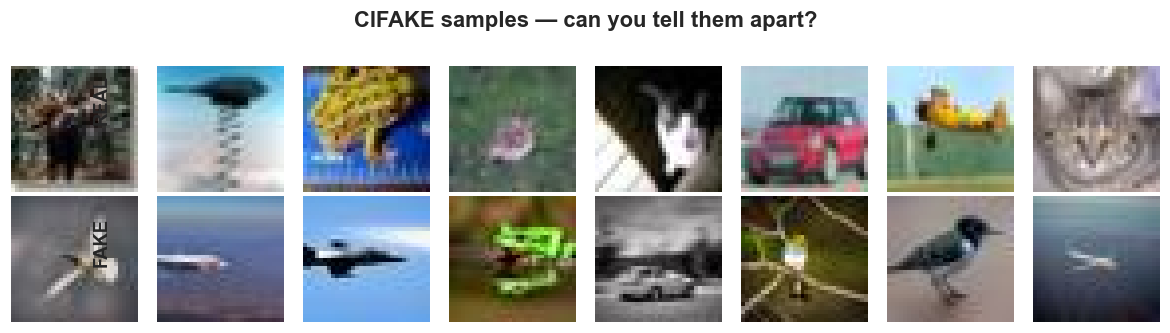

At 32x32 the two rows are essentially indistinguishable by eye.
Whatever separates them is not something a human reads off the pixels.


In [11]:
def show_grid(images: np.ndarray, labels: np.ndarray, n: int = 8, title: str = "") -> None:
    """Plot n real and n fake samples side by side."""
    rng = np.random.default_rng(SEED)
    real_ids = rng.choice(np.where(labels == 0)[0], n, replace=False)
    fake_ids = rng.choice(np.where(labels == 1)[0], n, replace=False)

    fig, axes = plt.subplots(2, n, figsize=(1.35 * n, 3.1))
    for col, (r_id, f_id) in enumerate(zip(real_ids, fake_ids)):
        axes[0, col].imshow(images[r_id])
        axes[1, col].imshow(images[f_id])
        for row in (0, 1):
            axes[row, col].axis("off")
    axes[0, 0].set_ylabel("REAL")
    axes[1, 0].set_ylabel("FAKE")
    fig.text(0.085, 0.72, "REAL", rotation=90, va="center", fontweight="bold")
    fig.text(0.085, 0.30, "FAKE", rotation=90, va="center", fontweight="bold")
    fig.suptitle(title or "CIFAKE samples — can you tell them apart?", fontweight="bold")
    plt.tight_layout()


show_grid(X_train, y_train, n=8)
save_fig("01_sample_grid")
plt.show()

print("At 32x32 the two rows are essentially indistinguishable by eye.")
print("Whatever separates them is not something a human reads off the pixels.")

### 4.2 Pixel statistics - is there a trivial shortcut?

Before building anything sophisticated, check whether the classes differ in some banal way (mean
brightness, saturation, contrast). If they did, a two-parameter model would solve the task and the rest
of the notebook would be theatre.

In [12]:
def pixel_stats(images: np.ndarray) -> dict:
    """Basic intensity statistics. Every reduction accumulates in float64 -- see the note
    in Section 5.1 on float32 summation saturating over tens of millions of values."""
    x = images.astype(np.float32) / 255.0
    f64 = {"dtype": np.float64}
    return {
        "mean_R": x[..., 0].mean(**f64), "mean_G": x[..., 1].mean(**f64),
        "mean_B": x[..., 2].mean(**f64),
        "std_R": x[..., 0].std(**f64), "std_G": x[..., 1].std(**f64),
        "std_B": x[..., 2].std(**f64),
        "mean_luma": x.mean(**f64),
        "mean_local_contrast": np.abs(np.diff(x, axis=2)).mean(**f64),
    }


sub = np.random.default_rng(SEED).choice(len(y_train), min(EDA_SAMPLE, len(y_train)), replace=False)
stats = pd.DataFrame(
    [pixel_stats(X_train[sub][y_train[sub] == 0]), pixel_stats(X_train[sub][y_train[sub] == 1])],
    index=["REAL", "FAKE"],
).T
stats["abs_diff"] = (stats["REAL"] - stats["FAKE"]).abs()
print(stats.round(4).to_string())
print(
    "\nDifferences are small. Local contrast is the largest gap, which is already a hint that the\n"
    "distinguishing information sits in high spatial frequencies rather than in global colour."
)

                       REAL    FAKE  abs_diff
mean_R               0.4908  0.4521    0.0387
mean_G               0.4815  0.4428    0.0387
mean_B               0.4464  0.3867    0.0597
std_R                0.2445  0.2285    0.0160
std_G                0.2422  0.2308    0.0115
std_B                0.2604  0.2682    0.0079
mean_luma            0.4729  0.4272    0.0457
mean_local_contrast  0.0563  0.0558    0.0005

Differences are small. Local contrast is the largest gap, which is already a hint that the
distinguishing information sits in high spatial frequencies rather than in global colour.


### 4.3 The spectral hypothesis - Figure 1

Generators build images by repeatedly upsampling a small latent grid. Every upsample-then-convolve step
imprints a periodic pattern, and periodicity in the spatial domain shows up as **localised energy peaks
in the Fourier domain**. Real photographs, formed by light hitting a sensor, have a smooth,
roughly power-law spectrum with no such structure.

We test this directly. For a batch of images we compute

$$ S(u,v) = \log\left(1 + \left|\mathcal{F}\{x\}(u,v)\right|\right) $$

with the zero frequency shifted to the centre, average it separately over real and fake images, and
subtract. If the hypothesis holds, the difference map will not be noise, it will have visible
structure at the high-frequency edges and corners.

In [13]:
# @smoke
def to_tensor01(images_uint8: np.ndarray) -> torch.Tensor:
    """uint8 [N,H,W,C] -> float32 tensor [N,C,H,W] in [0,1]."""
    x = torch.from_numpy(images_uint8).float().div_(255.0)
    return x.permute(0, 3, 1, 2).contiguous()


def log_magnitude_spectrum(x: torch.Tensor) -> torch.Tensor:
    """Centred log-magnitude spectrum of a batch. x: [B,C,H,W] -> [B,C,H,W].

    `norm="ortho"` keeps the transform unitary so spectrum magnitudes do not scale
    with image size, and `log1p` compresses the enormous dynamic range of |F| into
    a range a network can actually train on.
    """
    freq = torch.fft.fft2(x, norm="ortho")
    freq = torch.fft.fftshift(freq, dim=(-2, -1))
    return torch.log1p(freq.abs())


@torch.no_grad()
def mean_spectrum(images_uint8: np.ndarray, batch: int = 2048) -> np.ndarray:
    """Average centred log-magnitude spectrum over a set of images, as [H,W] (channel-averaged)."""
    total = torch.zeros(32, 32)
    n = 0
    for start in range(0, len(images_uint8), batch):
        chunk = to_tensor01(images_uint8[start : start + batch])
        spec = log_magnitude_spectrum(chunk).mean(dim=1)  # average over RGB
        total += spec.sum(dim=0)
        n += len(chunk)
    return (total / n).numpy()

Now apply it: average the spectrum separately over 10,000 real and 10,000 fake training images.

  saved -> results\figures\02_mean_spectrum_difference.png


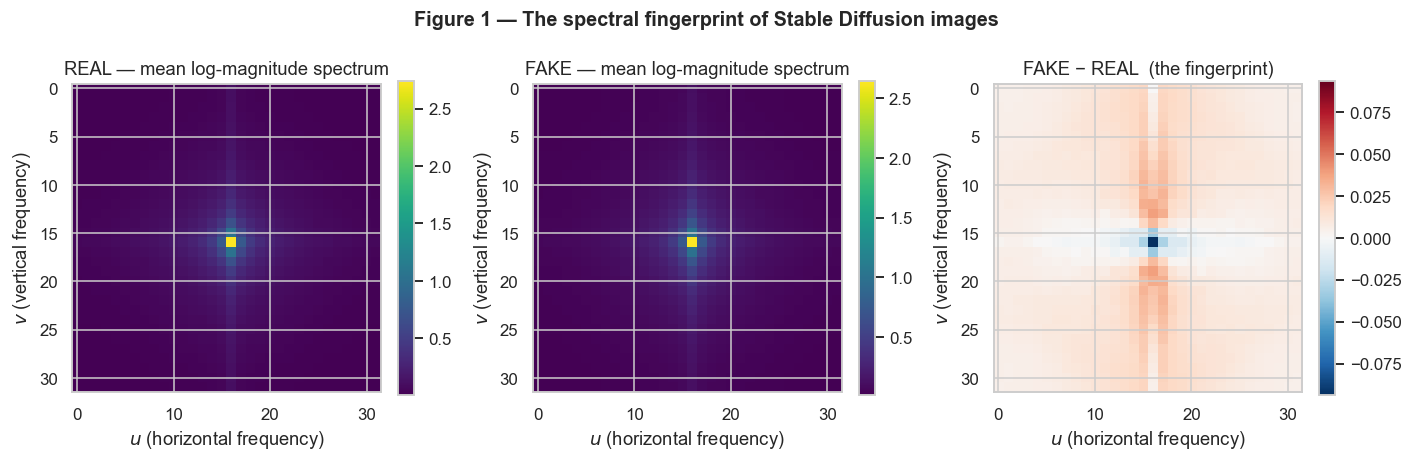

Max |difference| in log-magnitude: 0.0938
The difference map is clearly structured rather than noisy: fake images carry systematically
different energy at the high-frequency edges of the spectrum. This is the signal DSF-Net's
frequency stream is built to read.


In [14]:
eda_n = min(EDA_SAMPLE, len(y_train))
eda_ids = np.random.default_rng(SEED).choice(len(y_train), eda_n, replace=False)
eda_X, eda_y = X_train[eda_ids], y_train[eda_ids]

spec_real = mean_spectrum(eda_X[eda_y == 0])
spec_fake = mean_spectrum(eda_X[eda_y == 1])
spec_diff = spec_fake - spec_real

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
im0 = axes[0].imshow(spec_real, cmap="viridis")
axes[0].set_title("REAL — mean log-magnitude spectrum")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(spec_fake, cmap="viridis")
axes[1].set_title("FAKE — mean log-magnitude spectrum")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

lim = np.abs(spec_diff).max()
im2 = axes[2].imshow(spec_diff, cmap="RdBu_r", vmin=-lim, vmax=lim)
axes[2].set_title("FAKE − REAL  (the fingerprint)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("$u$ (horizontal frequency)")
    ax.set_ylabel("$v$ (vertical frequency)")
fig.suptitle(
    "Figure 1 — The spectral fingerprint of Stable Diffusion images",
    fontweight="bold", fontsize=13,
)
plt.tight_layout()
save_fig("02_mean_spectrum_difference")
plt.show()

print(f"Max |difference| in log-magnitude: {lim:.4f}")
print(
    "The difference map is clearly structured rather than noisy: fake images carry systematically\n"
    "different energy at the high-frequency edges of the spectrum. This is the signal DSF-Net's\n"
    "frequency stream is built to read."
)

### 4.4 The radial power spectrum

The 2D map above is 1,024 numbers. Most of its information collapses neatly into a 1D curve: the
**azimuthal average**, i.e. the mean spectral magnitude at each distance from the centre. This is the
classical "spectral fingerprint" plot from the deepfake-detection literature, and it turns the artefact
into a handful of interpretable features, cheap enough to feed a logistic regression (Section 6) and
useful enough to hand the network as a prior (Section 9).

In [15]:
# @smoke
N_RADIAL_BINS = 16


def build_radial_bins(size: int = 32, nbins: int = N_RADIAL_BINS):
    """Precompute the flat radius->bin index map and per-bin pixel counts for a size x size spectrum."""
    coords = torch.arange(size).float() - size // 2
    yy, xx = torch.meshgrid(coords, coords, indexing="ij")
    radius = torch.sqrt(xx**2 + yy**2)
    idx = (radius / (radius.max() + 1e-8) * (nbins - 1e-6)).long().clamp_(0, nbins - 1)
    counts = torch.bincount(idx.flatten(), minlength=nbins).float().clamp_(min=1.0)
    return idx.flatten(), counts


RADIAL_IDX, RADIAL_COUNTS = build_radial_bins()


def radial_profile(spectrum: torch.Tensor) -> torch.Tensor:
    """Azimuthal average of a centred spectrum. [B,C,H,W] -> [B, nbins] (channel-averaged)."""
    b = spectrum.shape[0]
    flat = spectrum.mean(dim=1).reshape(b, -1)               # [B, H*W]
    out = torch.zeros(b, N_RADIAL_BINS, device=spectrum.device, dtype=flat.dtype)
    out.index_add_(1, RADIAL_IDX.to(spectrum.device), flat)  # sum per ring
    return out / RADIAL_COUNTS.to(spectrum.device)           # mean per ring


@torch.no_grad()
def radial_features(images_uint8: np.ndarray, batch: int = 2048) -> np.ndarray:
    """Compute the 16-bin radial profile for every image."""
    feats = []
    for start in range(0, len(images_uint8), batch):
        chunk = to_tensor01(images_uint8[start : start + batch])
        feats.append(radial_profile(log_magnitude_spectrum(chunk)).numpy())
    return np.concatenate(feats, axis=0)

Compare the profiles of the two classes, and quantify the separation per ring with Cohen's $d$.

  saved -> results\figures\03_radial_profile.png


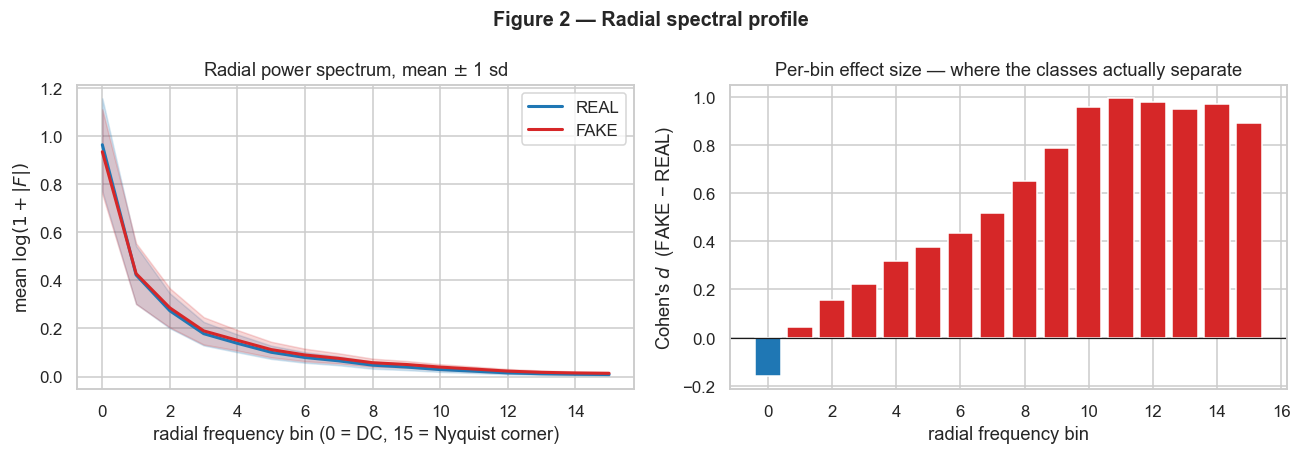

Largest separation at ring 11 with Cohen's d = +0.994
Effect sizes above ~0.5 in the outer rings confirm that a handful of hand-computed spectral
numbers already carry real discriminative signal. Section 7 turns exactly these 16 features
into our first, deliberately non-deep baseline.


In [16]:
rp = radial_features(eda_X)
rp_real, rp_fake = rp[eda_y == 0], rp[eda_y == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

rings = np.arange(N_RADIAL_BINS)
for arr, name, colour in [(rp_real, "REAL", "tab:blue"), (rp_fake, "FAKE", "tab:red")]:
    mu, sd = arr.mean(0), arr.std(0)
    axes[0].plot(rings, mu, label=name, color=colour, lw=2)
    axes[0].fill_between(rings, mu - sd, mu + sd, color=colour, alpha=0.18)
axes[0].set_xlabel("radial frequency bin (0 = DC, 15 = Nyquist corner)")
axes[0].set_ylabel(r"mean $\log(1+|F|)$")
axes[0].set_title("Radial power spectrum, mean $\\pm$ 1 sd")
axes[0].legend()

diff = rp_fake.mean(0) - rp_real.mean(0)
pooled = np.sqrt((rp_fake.var(0) + rp_real.var(0)) / 2) + 1e-8
axes[1].bar(rings, diff / pooled, color=np.where(diff > 0, "tab:red", "tab:blue"))
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("radial frequency bin")
axes[1].set_ylabel("Cohen's $d$  (FAKE − REAL)")
axes[1].set_title("Per-bin effect size — where the classes actually separate")

fig.suptitle("Figure 2 — Radial spectral profile", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("03_radial_profile")
plt.show()

best_bin = int(np.argmax(np.abs(diff / pooled)))
print(f"Largest separation at ring {best_bin} with Cohen's d = {diff[best_bin] / pooled[best_bin]:+.3f}")
print(
    "Effect sizes above ~0.5 in the outer rings confirm that a handful of hand-computed spectral\n"
    "numbers already carry real discriminative signal. Section 7 turns exactly these 16 features\n"
    "into our first, deliberately non-deep baseline."
)

## 5. Preprocessing, datasets and dataloaders

### 5.1 Normalisation statistics

Computed on **our training split only**: never on validation or test, and never copied from a
hard-coded CIFAR-10 constant, since half of these images did not come from CIFAR-10 at all.

In [17]:
# Accumulate in float64. Reducing ~92 million float32 values along the outer axes sums
# them sequentially in float32; once the running total passes ~4e7 the spacing between
# representable float32 values is 4.0, so adding another 0.45 is a no-op and the sum
# silently saturates. The first run of this notebook reported mean = [0.182, 0.182, 0.182]
# because of exactly that -- three identical channel means is the tell, since real RGB
# channels never agree to four decimals.
_train_float = X_train.astype(np.float32) / 255.0
CHANNEL_MEAN = _train_float.mean(axis=(0, 1, 2), dtype=np.float64).astype(np.float32)
CHANNEL_STD = _train_float.std(axis=(0, 1, 2), dtype=np.float64).astype(np.float32)
del _train_float

# Guard against the bug returning, without hard-coding what "plausible" pixel statistics
# look like: recompute the same statistics on a small random subsample. A few thousand
# images cannot saturate a float32 accumulator, so if the full-set numbers drift away from
# the probe, the full-set reduction is losing precision.
_probe_ids = np.random.default_rng(SEED).choice(len(X_train), 2000, replace=False)
_probe = X_train[_probe_ids].astype(np.float32) / 255.0
_probe_mean = _probe.mean(axis=(0, 1, 2), dtype=np.float64)
_probe_std = _probe.std(axis=(0, 1, 2), dtype=np.float64)
del _probe

assert np.allclose(CHANNEL_MEAN, _probe_mean, atol=0.02), (
    f"full-set mean {CHANNEL_MEAN} disagrees with a 2,000-image probe {_probe_mean.round(4)}; "
    "the full-set reduction is losing precision"
)
assert np.allclose(CHANNEL_STD, _probe_std, atol=0.02), (
    f"full-set std {CHANNEL_STD} disagrees with a 2,000-image probe {_probe_std.round(4)}; "
    "the full-set reduction is losing precision"
)
print(f"cross-check against a 2,000-image probe: mean {_probe_mean.round(4)} — consistent")

print(f"channel mean: {CHANNEL_MEAN.round(4)}")
print(f"channel std : {CHANNEL_STD.round(4)}")

MEAN_T = torch.tensor(CHANNEL_MEAN).view(1, 3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD).view(1, 3, 1, 1)

cross-check against a 2,000-image probe: mean [0.4729 0.4654 0.4188] — consistent
channel mean: [0.472  0.463  0.4179]
channel std : [0.2374 0.2373 0.2658]


### 5.2 Augmentation: a deliberately conservative choice

Standard practice for 32x32 classification would be random crop with padding, horizontal flip, colour
jitter, and often blur or JPEG noise. **We use horizontal flip only**, and this is a design decision
rather than an oversight.

The reasoning:

* A **horizontal flip** mirrors the Fourier magnitude spectrum about the vertical axis. The fingerprint
  is preserved, merely reflected, so the augmentation is free.
* **Random crop with padding** introduces a zero-padded border. Sharp artificial edges inject broadband
  high-frequency energy that lands directly on top of the fingerprint.
* **Colour jitter, blur, and recompression** attenuate high frequencies. They attack the signal itself.

In ordinary classification these transforms are harmless because the semantic content survives them.
Here, the *artefact* is the content, so the reasoning above predicts that heavy augmentation should
hurt. That is a prediction, not a result: Section 14 (ablation 7) trains the same model with a
conventional heavy augmentation stack and measures which way it actually goes. If the prediction
fails, that is reported as a failed prediction rather than quietly dropped.

In [18]:
def jpeg_compress(img_uint8: np.ndarray, quality: int) -> np.ndarray:
    """Round-trip a uint8 HWC image through real JPEG encoding at the given quality.

    Used both as a training-time augmentation (Section 15.3) and as the main test-time
    degradation (Section 15.1). It must be genuine JPEG rather than a blur approximation,
    because the effect we care about is JPEG's *quantisation of high-frequency DCT
    coefficients*, precisely where the generator fingerprint lives.
    """
    buffer = io.BytesIO()
    Image.fromarray(img_uint8).save(buffer, format="JPEG", quality=int(quality))
    buffer.seek(0)
    return np.array(Image.open(buffer).convert("RGB"), dtype=np.uint8)


class CifakeDataset(Dataset):
    """CIFAKE images held as uint8 in RAM, converted to normalised tensors on access.

    Parameters
    ----------
    images : uint8 array [N,32,32,3]
    labels : uint8 array [N], 1 = FAKE
    train  : if True, apply the (minimal) augmentation policy
    heavy_aug : if True, apply the conventional heavy stack instead, used only by ablation 7
    random_jpeg : if True, randomly JPEG-compress during training, the robustness
                  mitigation trained in Section 15.3
    degradation : optional callable applied to the uint8 image before tensor conversion,
                  used by the robustness study in Section 15
    """

    def __init__(self, images, labels, train=False, heavy_aug=False,
                 random_jpeg=False, degradation=None):
        self.images = images
        self.labels = labels.astype(np.float32)
        self.train = train
        self.heavy_aug = heavy_aug
        self.random_jpeg = random_jpeg
        self.degradation = degradation

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, i: int):
        img = self.images[i]

        if self.degradation is not None:
            img = self.degradation(img)

        if self.train and self.random_jpeg and random.random() < 0.5:
            img = jpeg_compress(img, random.randint(40, 95))

        if self.train and random.random() < 0.5:
            img = img[:, ::-1]  # horizontal flip

        x = torch.from_numpy(np.ascontiguousarray(img)).float().div_(255.0).permute(2, 0, 1)

        if self.train and self.heavy_aug:
            x = _heavy_augment(x)

        x = (x - MEAN_T[0]) / STD_T[0]
        return x, torch.tensor(self.labels[i])


def _heavy_augment(x: torch.Tensor) -> torch.Tensor:
    """The conventional augmentation stack, used ONLY for ablation 7 to show that it hurts."""
    # brightness / contrast jitter
    if random.random() < 0.8:
        x = (x * random.uniform(0.7, 1.3)).clamp(0, 1)
        m = x.mean()
        x = ((x - m) * random.uniform(0.7, 1.3) + m).clamp(0, 1)
    # random crop with zero padding
    if random.random() < 0.5:
        pad = F.pad(x, (4, 4, 4, 4))
        top, left = random.randint(0, 8), random.randint(0, 8)
        x = pad[:, top : top + 32, left : left + 32]
    # gaussian blur
    if random.random() < 0.3:
        k = torch.tensor([[1.0, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16.0
        k = k.view(1, 1, 3, 3).repeat(3, 1, 1, 1)
        x = F.conv2d(x.unsqueeze(0), k, padding=1, groups=3).squeeze(0)
    return x


def make_loader(dataset: Dataset, batch_size: int = 256, shuffle: bool = False) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2 if IN_COLAB else 0,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
        persistent_workers=IN_COLAB,
    )


BATCH_SIZE = 256

train_ds = CifakeDataset(X_train, y_train, train=True)
val_ds = CifakeDataset(X_val, y_val)
test_ds = CifakeDataset(X_test, y_test)

train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_ds, BATCH_SIZE)
test_loader = make_loader(test_ds, BATCH_SIZE)

xb, yb = next(iter(train_loader))
print(f"batch x {tuple(xb.shape)} dtype {xb.dtype} | y {tuple(yb.shape)}")
print(f"x range after normalisation: [{xb.min():.2f}, {xb.max():.2f}]")
print(f"batch fake ratio: {yb.mean():.3f}")

batch x (256, 3, 32, 32) dtype torch.float32 | y (256,)
x range after normalisation: [-1.99, 2.26]
batch fake ratio: 0.410


## 6. Metrics and the shared training harness

Every neural model in this notebook, both baselines and every DSF-Net variant, is trained by the
*same* `train_model` function and scored by the *same* `compute_metrics` function. This is the only way
the comparison table in Section 13 means anything: if each model had its own bespoke loop, differences
in schedule or early stopping would masquerade as differences in architecture.

### 6.1 Metrics

We report more than accuracy, because accuracy alone hides the behaviour that matters for a forensic
tool:

* **ROC-AUC / PR-AUC**: threshold-free ranking quality. Our model-selection criterion is ROC-AUC.
* **Precision / recall / F1** for the `FAKE` class, recall is the operationally important one: a missed
  fake is the expensive error.
* **Expected Calibration Error (ECE)**: when the model says "97% fake", is it right 97% of the time?
  Detectors are notoriously overconfident, and a miscalibrated score is unusable for triage.

In [19]:
# @smoke
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, roc_curve,
)


def expected_calibration_error(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 15) -> float:
    """ECE: average |confidence - accuracy| over equal-width confidence bins."""
    conf = np.maximum(y_prob, 1 - y_prob)          # confidence in the predicted class
    pred = (y_prob >= 0.5).astype(int)
    correct = (pred == y_true).astype(float)

    edges = np.linspace(0.5, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    """All headline metrics for one model on one split. Positive class = FAKE."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def measure_latency(model: nn.Module, batch_size: int = 256, n_iter: int = 30) -> float:
    """Inference throughput in images/second, after warm-up."""
    model.eval().to(DEVICE)
    dummy = torch.randn(batch_size, 3, 32, 32, device=DEVICE)
    for _ in range(5):
        model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(n_iter):
        model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return (batch_size * n_iter) / (time.perf_counter() - start)

### 6.2 Training configuration

Defaults chosen for this task and then refined in Section 12:

| Setting | Value | Why |
|---|---|---|
| Optimiser | AdamW, `lr=3e-4`, `wd=1e-4` | Decoupled weight decay behaves better than Adam's L2 on small models |
| Schedule | 2-epoch linear warmup + cosine decay | Warmup stops the constrained front-end from being wrecked by a large first step |
| Loss | `BCEWithLogitsLoss` + label smoothing 0.05 | Logit-space loss is numerically stable; smoothing curbs overconfidence (see ECE) |
| Grad clipping | 1.0 | The frequency stream sees a log-magnitude input with occasional large values |
| Early stopping | patience 5 on **val ROC-AUC** | AUC, not loss, we care about ranking, and loss is distorted by smoothing |
| Precision | AMP (fp16) | ~2x faster; the FFT itself is forced back to fp32 (complex-half is unreliable) |

In [20]:
# @smoke
@dataclass
class TrainConfig:
    epochs: int = 30
    lr: float = 3e-4
    weight_decay: float = 1e-4
    warmup_epochs: int = 2
    label_smoothing: float = 0.05
    grad_clip: float = 1.0
    patience: int = 5
    seed: int = 42

    def __post_init__(self):
        # In quick mode every run is truncated to 2 epochs with no early stopping, so the
        # whole notebook still exercises every code path without waiting for convergence.
        if QUICK_RUN:
            self.epochs = min(self.epochs, 2)
            self.warmup_epochs = min(self.warmup_epochs, 1)
            self.patience = max(self.patience, self.epochs)

    def to_dict(self) -> dict:
        return asdict(self)


def smooth_targets(y: torch.Tensor, eps: float) -> torch.Tensor:
    """Symmetric label smoothing for binary targets: 1 -> 1-eps, 0 -> eps."""
    return y * (1.0 - 2.0 * eps) + eps


def build_scheduler(optimizer, cfg: TrainConfig, steps_per_epoch: int):
    """Linear warmup then cosine decay, stepped per batch."""
    warmup_steps = max(1, cfg.warmup_epochs * steps_per_epoch)
    total_steps = max(warmup_steps + 1, cfg.epochs * steps_per_epoch)

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

### 6.3 Evaluation and training loops

`train_model` is **resumable**: it writes `<name>_last.pt` (model + optimiser + scheduler + epoch)
after every epoch and `<name>_best.pt` whenever validation AUC improves. If a Colab session dies
mid-run, re-executing the cell picks up exactly where it stopped.

In [21]:
# @smoke
@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    """Return (y_true, y_prob) for a whole loader. y_prob is P(FAKE)."""
    model.eval().to(DEVICE)
    probs, trues = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            logits = model(xb)
        probs.append(torch.sigmoid(logits.float().squeeze(-1)).cpu().numpy())
        trues.append(yb.numpy())
    return np.concatenate(trues), np.concatenate(probs)


def train_model(
    model: nn.Module,
    name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    cfg: TrainConfig = TrainConfig(),
    resume: bool = True,
    verbose: bool = True,
) -> dict:
    """Train one model, returning its history dict. Best weights are loaded back into `model`."""
    seed_everything(cfg.seed)
    model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = build_scheduler(optimizer, cfg, len(train_loader))
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=AMP_ENABLED)
    criterion = nn.BCEWithLogitsLoss()

    best_path = CKPT_DIR / f"{name}_best.pt"
    last_path = CKPT_DIR / f"{name}_last.pt"

    history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}
    start_epoch, best_auc, epochs_without_improvement = 0, -np.inf, 0

    if resume and last_path.exists():
        ckpt = torch.load(last_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        scaler.load_state_dict(ckpt["scaler"])
        history = ckpt["history"]
        start_epoch, best_auc = ckpt["epoch"] + 1, ckpt["best_auc"]
        epochs_without_improvement = ckpt["stale"]
        if verbose:
            print(f"[{name}] resuming from epoch {start_epoch} (best val AUC {best_auc:.4f})")

    if start_epoch >= cfg.epochs and best_path.exists():
        model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=False)["model"])
        # Summary keys are normally written at the end of training. On this early-return
        # path they have to be filled in too, or every caller that reads them breaks the
        # second time the notebook is run.
        history.setdefault("train_time_s", 0.0)
        history["best_val_auc"] = best_auc
        if verbose:
            print(f"[{name}] already trained — loaded best weights (val AUC {best_auc:.4f})")
        return history

    t0 = time.time()
    for epoch in range(start_epoch, cfg.epochs):
        model.train()
        running, seen = 0.0, 0
        bar = tqdm(train_loader, desc=f"[{name}] epoch {epoch + 1}/{cfg.epochs}", leave=False)
        for xb, yb in bar:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            target = smooth_targets(yb, cfg.label_smoothing)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                logits = model(xb).squeeze(-1)
                loss = criterion(logits.float(), target)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            # Re-impose the Bayar-Stamm constraint after the weights have moved.
            if hasattr(model, "project_constraints"):
                model.project_constraints()

            running += loss.item() * len(yb)
            seen += len(yb)
            bar.set_postfix(loss=f"{running / seen:.4f}")

        y_true, y_prob = predict(model, val_loader)
        # Plain (unsmoothed) BCE on the validation set, so the number stays comparable
        # across configs that use different label smoothing.
        p = np.clip(y_prob, 1e-7, 1 - 1e-7)
        val_loss = float(-(y_true * np.log(p) + (1 - y_true) * np.log(1 - p)).mean())
        val_acc = accuracy_score(y_true, (y_prob >= 0.5).astype(int))
        val_auc = roc_auc_score(y_true, y_prob)

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(running / seen)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        improved = val_auc > best_auc + 1e-5
        if improved:
            best_auc, epochs_without_improvement = val_auc, 0
            torch.save({"model": model.state_dict(), "epoch": epoch, "val_auc": val_auc}, best_path)
        else:
            epochs_without_improvement += 1

        torch.save(
            {
                "model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                "history": history, "epoch": epoch, "best_auc": best_auc,
                "stale": epochs_without_improvement,
            },
            last_path,
        )

        if verbose:
            flag = "  <- best" if improved else ""
            print(
                f"[{name}] epoch {epoch + 1:2d}/{cfg.epochs} | "
                f"train {running / seen:.4f} | val loss {val_loss:.4f} | "
                f"val acc {val_acc:.4f} | val AUC {val_auc:.4f}{flag}"
            )

        if epochs_without_improvement >= cfg.patience:
            if verbose:
                print(f"[{name}] early stopping at epoch {epoch + 1} (no AUC gain for {cfg.patience})")
            break

    model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=False)["model"])
    history["train_time_s"] = time.time() - t0
    history["best_val_auc"] = best_auc
    if verbose:
        print(f"[{name}] done in {history['train_time_s']:.0f}s | best val AUC {best_auc:.4f}")
    return history

## 7. Baseline 1 - classical radial-spectrum classifier

The first baseline uses **no deep learning at all**: logistic regression and a linear SVM on the 16
radial-spectrum features from Section 4.4.

Its job is to answer a question that a purely neural comparison cannot: *how much of this task is
solved by the hand-designed spectral feature alone?* Whatever accuracy this reaches is the floor that
the frequency stream of DSF-Net must clear to justify its parameters.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("Computing radial spectral features...")
Rtr = radial_features(X_train)
Rva = radial_features(X_val)
Rte = radial_features(X_test)
print(f"feature matrices: train {Rtr.shape}, val {Rva.shape}, test {Rte.shape}")

classical_results = {}

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
logreg.fit(Rtr, y_train)
classical_results["Spectral-LogReg"] = {
    "val": compute_metrics(y_val, logreg.predict_proba(Rva)[:, 1]),
    "model": logreg,
}

svm = make_pipeline(StandardScaler(), LinearSVC(C=0.1, max_iter=5000))
svm.fit(Rtr, y_train)
# LinearSVC has no predict_proba; the decision function is a valid ranking score for AUC,
# and a sigmoid squashing gives a usable (if uncalibrated) probability for the other metrics.
classical_results["Spectral-LinearSVM"] = {
    "val": compute_metrics(y_val, 1 / (1 + np.exp(-svm.decision_function(Rva)))),
    "model": svm,
}

for name, res in classical_results.items():
    m = res["val"]
    print(f"{name:22s} val acc {m['accuracy']:.4f} | val AUC {m['roc_auc']:.4f} | F1 {m['f1']:.4f}")

print(
    "\nA 16-feature linear model already beats chance by a wide margin, using nothing but the\n"
    "azimuthal average of the Fourier magnitude. The spectral hypothesis from Section 4 holds."
)

Computing radial spectral features...


feature matrices: train (90000, 16), val (10000, 16), test (20000, 16)


Spectral-LogReg        val acc 0.7842 | val AUC 0.8560 | F1 0.7785
Spectral-LinearSVM     val acc 0.7807 | val AUC 0.8559 | F1 0.7720

A 16-feature linear model already beats chance by a wide margin, using nothing but the
azimuthal average of the Fourier magnitude. The spectral hypothesis from Section 4 holds.


## 8. Baseline 2 - the CIFAKE reference CNN

A reimplementation of the small CNN described by Bird & Lotfi (2024): two convolutional layers of 32
filters each with max-pooling, followed by a small dense layer. This study reports **92.98%** test
accuracy with this design, which gives us a published number to check ourselves against on the
identical split.

It is also the honest "what a sensible person would try first" baseline: a plain CNN on the raw pixels,
with no frequency information and no forensic front-end.

In [23]:
# @smoke
class CifakeCNN(nn.Module):
    """Small CNN following the architecture described in the CIFAKE paper.

    Conv(32) -> ReLU -> MaxPool -> Conv(32) -> ReLU -> MaxPool -> Dense(64) -> Dense(1)
    """

    def __init__(self, dropout: float = 0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),   # 32 -> 16
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),  # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 64), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


_m = CifakeCNN()
print(f"CifakeCNN parameters: {count_parameters(_m):,}")
print(f"output shape for a 4-image batch: {tuple(_m(torch.randn(4, 3, 32, 32)).shape)}")
del _m

CifakeCNN parameters: 141,345
output shape for a 4-image batch: (4, 1)


## 9. Baseline 3 - ResNet-18 transfer learning

The strong, conventional deep baseline: ImageNet-pretrained ResNet-18, fully fine-tuned.

Two adaptations are required for 32x32 input, and both are standard practice for CIFAR-scale data:

* the 7x7 stride-2 stem is replaced by a 3x3 stride-1 convolution, and
* the following max-pool is removed.

Without these, a 32x32 image is reduced to 8x8 before the first residual block and most of the spatial
detail, including all of the fingerprint, is destroyed immediately. The replaced stem is randomly
initialised; every deeper layer keeps its pretrained weights.

This model has roughly **11M parameters**, about 10x DSF-Net. If a compact custom architecture can
match it, that is a result worth reporting.

In [24]:
# @smoke
from torchvision.models import resnet18, ResNet18_Weights


def build_resnet18(pretrained: bool = True) -> nn.Module:
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model


_m = build_resnet18(pretrained=False)
print(f"ResNet-18 (adapted) parameters: {count_parameters(_m):,}")
print(f"output shape for a 4-image batch: {tuple(_m(torch.randn(4, 3, 32, 32)).shape)}")
del _m

ResNet-18 (adapted) parameters: 11,169,345
output shape for a 4-image batch: (4, 1)


## 10. DSF-Net - the custom architecture

```
                    input 32x32x3  (augmented, normalised)
                                |
         +----------------------+----------------------+
         |                                             |
   SPATIAL STREAM                              FREQUENCY STREAM
   ConstrainedConv2d 5x5 (Bayar-Stamm)         fft2 -> fftshift -> log(1+|F|)
   centre = -1, remaining weights sum to 1                |
         |                                    +----------+-----------+
   stem Conv3x3 -> BN -> SiLU                 |                      |
   ResBlock  32ch  @32x32                SpecCNN (GroupNorm)   radial profile
   ResBlock  64ch  @16x16                3 convs, 32->64ch     16 bins -> MLP
   ResBlock 128ch  @8x8                       |                      |
         |                                  GAP 64-d              32-d
    GAP -> z_s (128-d)                         +---------+----------+
         |                                          z_f (96-d)
         +-------------------> GATED FUSION <------------+
                    g = sigmoid(W [z_s ; z_f] + b)          (128-d gate)
                    z = g * P_s(z_s) + (1 - g) * P_f(z_f)
                                |
            LayerNorm -> Dropout -> Linear(128->64) -> SiLU -> Linear(64->1)
                                |
                         BCEWithLogitsLoss
```

### 10.1 Design justification

**Constrained convolution front-end.** Taken from Bayar & Stamm's forensic CNN. After every optimiser
step the 5x5 kernels are re-projected so the centre tap is `-1` and the remaining taps sum to `+1`.
That makes each filter compute `prediction - actual` for the centre pixel: a **prediction residual**.
Image content is largely predictable from neighbouring pixels and cancels; the generator's
high-frequency artefact does not. The layer uses 3 filters, as in the original paper.

**Log-magnitude spectrum, not raw FFT.** `|F|` spans several orders of magnitude, so `log(1+|F|)`
compresses it into a trainable range. We discard phase deliberately: the fingerprint is a *magnitude*
periodicity, and phase mostly encodes the image content we are trying to suppress.

**GroupNorm in the frequency stream.** Per-image spectral scale varies enormously with content;
BatchNorm's running statistics are unstable under that, whereas GroupNorm normalises within each
sample.

**Radial profile as an explicit prior.** The 16-bin azimuthal average from Section 4.4 gave a linear
model real signal for free. Feeding it in alongside the learned spectral features means the network
starts from that prior instead of having to rediscover it.

**SiLU rather than ReLU.** Smooth and non-monotonic, with no dead-unit region, worth having when the
input signal is a low-amplitude residual and gradients are correspondingly small.

**Gated fusion, the core idea.** Concatenation forces the head to use both streams with fixed
weighting. A gate is meant to let the network decide *per image and per feature dimension* how much to
trust each stream. Crucially, `g` is a number we can read out, which makes the design falsifiable in
two separate ways: ablations 3 vs 4 test whether gating buys accuracy over concatenation, and Section
15.2 plots `g` under degradation to test whether the network actually abandons the frequency stream
once JPEG compression has destroyed the spectrum. This is the central architectural claim of the
project. **Both halves of it fail; Sections 18.1 and 18.3 report exactly how.**

In [25]:
# @smoke
def _round8(channels: float) -> int:
    """Round a width-scaled channel count to a multiple of 8 (keeps GroupNorm valid and kernels fast)."""
    return max(8, int(round(channels / 8.0)) * 8)


class ConstrainedConv2d(nn.Conv2d):
    """Bayar-Stamm constrained convolution: centre tap = -1, remaining taps sum to +1.

    The constraint is not differentiable, so it is enforced by projection: after each
    optimiser step `project()` renormalises the kernel back onto the constraint set.
    """

    def __init__(self, in_channels: int = 3, out_channels: int = 3, kernel_size: int = 5):
        super().__init__(in_channels, out_channels, kernel_size,
                         padding=kernel_size // 2, bias=False)
        self.centre = kernel_size // 2
        self.project()

    @torch.no_grad()
    def project(self) -> None:
        w = self.weight.data
        c = self.centre
        w[:, :, c, c] = 0.0
        total = w.sum(dim=(2, 3), keepdim=True)
        safe = torch.where(total.abs() < 1e-6, torch.full_like(total, 1e-6), total)
        w.div_(safe)
        w[:, :, c, c] = -1.0


class ResBlock(nn.Module):
    """Pre-activation-free residual block: Conv-BN-SiLU-Conv-BN + projection shortcut."""

    def __init__(self, c_in: int, c_out: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        self.act = nn.SiLU(inplace=True)
        self.shortcut = (
            nn.Identity()
            if stride == 1 and c_in == c_out
            else nn.Sequential(nn.Conv2d(c_in, c_out, 1, stride=stride, bias=False),
                               nn.BatchNorm2d(c_out))
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + self.shortcut(x))


class SpatialStream(nn.Module):
    """Pixel-domain stream with an optional forensic high-pass front-end."""

    def __init__(self, width: float = 1.0, use_constrained: bool = True):
        super().__init__()
        c1, c2, c3 = _round8(32 * width), _round8(64 * width), _round8(128 * width)
        self.front = ConstrainedConv2d(3, 3, 5) if use_constrained else nn.Identity()
        self.stem = nn.Sequential(
            nn.Conv2d(3, c1, 3, padding=1, bias=False), nn.BatchNorm2d(c1), nn.SiLU(inplace=True)
        )
        self.block1 = ResBlock(c1, c1)              # 32x32
        self.block2 = ResBlock(c1, c2, stride=2)    # 16x16
        self.block3 = ResBlock(c2, c3, stride=2)    # 8x8
        self.out_dim = c3

    def feature_map(self, x: torch.Tensor) -> torch.Tensor:
        """The final 8x8 map, the target layer for Grad-CAM in Section 15."""
        return self.block3(self.block2(self.block1(self.stem(self.front(x)))))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.feature_map(x).mean(dim=(2, 3))


class FrequencyStream(nn.Module):
    """Spectral stream: a CNN over the centred log-magnitude spectrum plus its radial profile."""

    def __init__(self, width: float = 1.0, use_radial: bool = True, n_bins: int = N_RADIAL_BINS):
        super().__init__()
        c1, c2 = _round8(32 * width), _round8(64 * width)
        self.spec_cnn = nn.Sequential(
            nn.Conv2d(3, c1, 3, padding=1, bias=False), nn.GroupNorm(8, c1), nn.SiLU(inplace=True),
            nn.Conv2d(c1, c1, 3, stride=2, padding=1, bias=False), nn.GroupNorm(8, c1), nn.SiLU(inplace=True),
            nn.Conv2d(c1, c2, 3, stride=2, padding=1, bias=False), nn.GroupNorm(8, c2), nn.SiLU(inplace=True),
        )
        self.use_radial = use_radial
        self.n_bins = n_bins
        if use_radial:
            idx, counts = build_radial_bins(32, n_bins)
            self.register_buffer("radial_idx", idx, persistent=False)
            self.register_buffer("radial_counts", counts, persistent=False)
            self.radial_mlp = nn.Sequential(
                nn.Linear(n_bins, 64), nn.SiLU(inplace=True),
                nn.Linear(64, 32), nn.SiLU(inplace=True),
            )
        self.out_dim = c2 + (32 if use_radial else 0)

    @staticmethod
    def spectrum(x: torch.Tensor) -> torch.Tensor:
        """Centred log-magnitude spectrum, always computed in fp32.

        AMP is disabled here on purpose: complex-half support is patchy across
        PyTorch builds, and the FFT is a negligible fraction of the runtime anyway.
        """
        with torch.autocast(device_type=x.device.type, enabled=False):
            freq = torch.fft.fft2(x.float(), norm="ortho")
            freq = torch.fft.fftshift(freq, dim=(-2, -1))
            return torch.log1p(freq.abs())

    def _radial(self, spec: torch.Tensor) -> torch.Tensor:
        b = spec.shape[0]
        flat = spec.mean(dim=1).reshape(b, -1)
        out = torch.zeros(b, self.n_bins, device=spec.device, dtype=flat.dtype)
        out.index_add_(1, self.radial_idx, flat)
        return out / self.radial_counts

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        spec = self.spectrum(x)
        z = self.spec_cnn(spec).mean(dim=(2, 3))
        if self.use_radial:
            z = torch.cat([z, self.radial_mlp(self._radial(spec))], dim=1)
        return z


class GatedFusion(nn.Module):
    """Per-dimension convex combination of two projected stream embeddings.

    g = sigmoid(W [z_s ; z_f] + b)      z = g * P_s(z_s) + (1 - g) * P_f(z_f)

    g is returned alongside z so it can be inspected, a high g means "this image is
    being judged mostly on its pixels", a low g means "mostly on its spectrum".
    """

    def __init__(self, dim_s: int, dim_f: int, dim_out: int = 128):
        super().__init__()
        self.proj_s = nn.Linear(dim_s, dim_out)
        self.proj_f = nn.Linear(dim_f, dim_out)
        self.gate = nn.Linear(dim_s + dim_f, dim_out)
        self.out_dim = dim_out

    def forward(self, z_s: torch.Tensor, z_f: torch.Tensor):
        g = torch.sigmoid(self.gate(torch.cat([z_s, z_f], dim=1)))
        return g * self.proj_s(z_s) + (1.0 - g) * self.proj_f(z_f), g


@dataclass
class DSFConfig:
    """Every ablation in Section 14 is one of these configs."""

    mode: str = "gated"           # 'gated' | 'concat' | 'spatial' | 'freq'
    width: float = 1.0
    fusion_dim: int = 128
    dropout: float = 0.3
    use_constrained: bool = True
    use_radial: bool = True


class DSFNet(nn.Module):
    """Dual-Stream Forensic Network.

    A single class covers the full model and every ablation variant, so that all
    comparisons differ only in the flags that are actually under test.
    """

    def __init__(self, cfg: DSFConfig = DSFConfig()):
        super().__init__()
        self.cfg = cfg
        assert cfg.mode in {"gated", "concat", "spatial", "freq"}

        self.spatial = (
            SpatialStream(cfg.width, cfg.use_constrained)
            if cfg.mode != "freq" else None
        )
        self.frequency = (
            FrequencyStream(cfg.width, cfg.use_radial)
            if cfg.mode != "spatial" else None
        )

        if cfg.mode == "gated":
            self.fusion = GatedFusion(self.spatial.out_dim, self.frequency.out_dim, cfg.fusion_dim)
            head_dim = cfg.fusion_dim
        elif cfg.mode == "concat":
            self.fusion = nn.Linear(self.spatial.out_dim + self.frequency.out_dim, cfg.fusion_dim)
            head_dim = cfg.fusion_dim
        elif cfg.mode == "spatial":
            self.fusion = None
            head_dim = self.spatial.out_dim
        else:
            self.fusion = None
            head_dim = self.frequency.out_dim

        self.head = nn.Sequential(
            nn.LayerNorm(head_dim),
            nn.Dropout(cfg.dropout),
            nn.Linear(head_dim, 64), nn.SiLU(inplace=True),
            nn.Linear(64, 1),
        )

    def embed(self, x: torch.Tensor):
        """Return (fused embedding, gate or None). The embedding is what t-SNE visualises."""
        if self.cfg.mode == "spatial":
            return self.spatial(x), None
        if self.cfg.mode == "freq":
            return self.frequency(x), None

        z_s, z_f = self.spatial(x), self.frequency(x)
        if self.cfg.mode == "gated":
            return self.fusion(z_s, z_f)
        return self.fusion(torch.cat([z_s, z_f], dim=1)), None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z, _ = self.embed(x)
        return self.head(z)

    @torch.no_grad()
    def project_constraints(self) -> None:
        """Re-impose the Bayar-Stamm constraint. Called by train_model after every step."""
        for module in self.modules():
            if isinstance(module, ConstrainedConv2d):
                module.project()

### 10.2 Shape and sanity checks

Before spending GPU hours, verify that every variant builds, produces the right output shape, back-
propagates, and that the constraint projection actually holds.

In [26]:
# @smoke
_variants = {
    "gated (full)": DSFConfig(mode="gated"),
    "concat": DSFConfig(mode="concat"),
    "spatial only": DSFConfig(mode="spatial"),
    "frequency only": DSFConfig(mode="freq"),
    "no constrained conv": DSFConfig(mode="gated", use_constrained=False),
    "no radial features": DSFConfig(mode="gated", use_radial=False),
}

_x = torch.randn(4, 3, 32, 32)
rows = []
for label, cfg in _variants.items():
    net = DSFNet(cfg)
    out = net(_x)
    assert out.shape == (4, 1), f"{label}: bad output shape {tuple(out.shape)}"
    out.sum().backward()  # gradients must flow through both streams
    rows.append({"variant": label, "params": count_parameters(net), "output": str(tuple(out.shape))})
print(pd.DataFrame(rows).to_string(index=False))

# Verify the Bayar-Stamm constraint is satisfied after projection.
_net = DSFNet(DSFConfig(mode="gated"))
_net.project_constraints()
_w = _net.spatial.front.weight.data
_c = _net.spatial.front.centre
print(f"\nConstrained kernel centre taps (should all be -1): {_w[:, 0, _c, _c].tolist()}")
print(f"Sum of remaining taps per filter (should all be +1): "
      f"{[round(float(_w[i, 0].sum() + 1.0), 5) for i in range(_w.shape[0])]}")

# Confirm the fusion gate is in range and actually varies across samples.
_z, _g = _net.embed(_x)
print(f"\nfused embedding {tuple(_z.shape)} | gate {tuple(_g.shape)} "
      f"in [{_g.min():.3f}, {_g.max():.3f}], per-sample std {_g.std(dim=1).mean():.3f}")
del _net, _x, _z, _g

            variant  params output
       gated (full)  405826 (4, 1)
             concat  376898 (4, 1)
       spatial only  316162 (4, 1)
     frequency only   38401 (4, 1)
no constrained conv  405601 (4, 1)
 no radial features  394466 (4, 1)

Constrained kernel centre taps (should all be -1): [-1.0, -1.0, -1.0]
Sum of remaining taps per filter (should all be +1): [1.0, 1.0, 1.0]

fused embedding (4, 128) | gate (4, 128) in [0.332, 0.656], per-sample std 0.049


## 11. Training the neural models

All three neural models are trained with the same harness. The only deviation is the learning rate for
ResNet-18: fine-tuning pretrained weights at `3e-4` destroys them, so it gets `1e-4`, which is standard
practice. Giving a baseline its best shot is the point, a baseline crippled by a badly chosen learning
rate would make DSF-Net look good for the wrong reason.

In [27]:
BASE_CFG = TrainConfig(epochs=30, lr=3e-4, weight_decay=1e-4, patience=5, seed=SEED)
RESNET_CFG = TrainConfig(epochs=20, lr=1e-4, weight_decay=1e-4, patience=5, seed=SEED)

models: dict[str, nn.Module] = {}
histories: dict[str, dict] = {}

models["CIFAKE-CNN"] = CifakeCNN()
histories["CIFAKE-CNN"] = train_model(
    models["CIFAKE-CNN"], "cifake_cnn", train_loader, val_loader, BASE_CFG
)

[cifake_cnn] epoch 1/30:   0%|          | 0/352 [00:00<?, ?it/s]

[cifake_cnn] epoch  1/30 | train 0.5762 | val loss 0.4160 | val acc 0.8236 | val AUC 0.9008  <- best


[cifake_cnn] epoch 2/30:   0%|          | 0/352 [00:00<?, ?it/s]

[cifake_cnn] epoch  2/30 | train 0.4419 | val loss 0.3359 | val acc 0.8627 | val AUC 0.9451  <- best


[cifake_cnn] epoch 3/30:   0%|          | 0/352 [00:00<?, ?it/s]

...

[cifake_cnn] epoch 28/30 | train 0.2889 | val loss 0.1667 | val acc 0.9485 | val AUC 0.9896  <- best


[cifake_cnn] epoch 29/30:   0%|          | 0/352 [00:00<?, ?it/s]

[cifake_cnn] epoch 29/30 | train 0.2889 | val loss 0.1667 | val acc 0.9483 | val AUC 0.9896


[cifake_cnn] epoch 30/30:   0%|          | 0/352 [00:00<?, ?it/s]

[cifake_cnn] epoch 30/30 | train 0.2888 | val loss 0.1668 | val acc 0.9485 | val AUC 0.9896
[cifake_cnn] done in 216s | best val AUC 0.9896


In [28]:
models["ResNet-18"] = build_resnet18(pretrained=True)
histories["ResNet-18"] = train_model(
    models["ResNet-18"], "resnet18", train_loader, val_loader, RESNET_CFG
)

[resnet18] epoch 1/20:   0%|          | 0/352 [00:00<?, ?it/s]

[resnet18] epoch  1/20 | train 0.4281 | val loss 0.1940 | val acc 0.9374 | val AUC 0.9847  <- best


[resnet18] epoch 2/20:   0%|          | 0/352 [00:00<?, ?it/s]

[resnet18] epoch  2/20 | train 0.2805 | val loss 0.1551 | val acc 0.9585 | val AUC 0.9909  <- best


[resnet18] epoch 3/20:   0%|          | 0/352 [00:00<?, ?it/s]

...

[resnet18] epoch 18/20 | train 0.1991 | val loss 0.0971 | val acc 0.9778 | val AUC 0.9970


[resnet18] epoch 19/20:   0%|          | 0/352 [00:00<?, ?it/s]

[resnet18] epoch 19/20 | train 0.1991 | val loss 0.0979 | val acc 0.9768 | val AUC 0.9969


[resnet18] epoch 20/20:   0%|          | 0/352 [00:00<?, ?it/s]

[resnet18] epoch 20/20 | train 0.1990 | val loss 0.0978 | val acc 0.9771 | val AUC 0.9971  <- best
[resnet18] done in 478s | best val AUC 0.9971


In [29]:
models["DSF-Net"] = DSFNet(DSFConfig(mode="gated"))
histories["DSF-Net"] = train_model(
    models["DSF-Net"], "dsfnet", train_loader, val_loader, BASE_CFG
)

[dsfnet] epoch 1/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet] epoch  1/30 | train 0.4770 | val loss 0.2628 | val acc 0.9055 | val AUC 0.9653  <- best


[dsfnet] epoch 2/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet] epoch  2/30 | train 0.3413 | val loss 0.2150 | val acc 0.9222 | val AUC 0.9784  <- best


[dsfnet] epoch 3/30:   0%|          | 0/352 [00:00<?, ?it/s]

...

[dsfnet] epoch 15/30 | train 0.2405 | val loss 0.1585 | val acc 0.9514 | val AUC 0.9892


[dsfnet] epoch 16/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet] epoch 16/30 | train 0.2363 | val loss 0.1467 | val acc 0.9572 | val AUC 0.9903


[dsfnet] epoch 17/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet] epoch 17/30 | train 0.2317 | val loss 0.1435 | val acc 0.9568 | val AUC 0.9895
[dsfnet] early stopping at epoch 17 (no AUC gain for 5)
[dsfnet] done in 209s | best val AUC 0.9910


### 11.1 Training curves

What to look for: whether validation AUC plateaus (enough epochs), whether train loss keeps falling
while validation AUC stalls (overfitting), and whether the warmup segment is visible in the LR trace.

  saved -> results\figures\04_training_curves.png


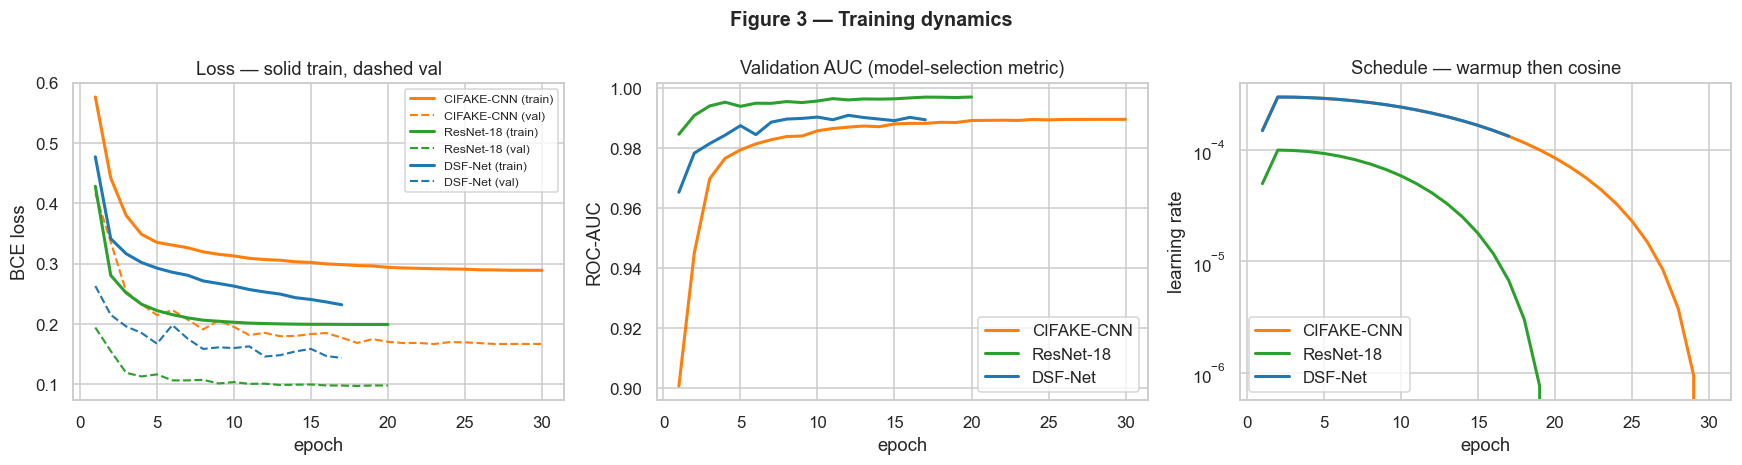

CIFAKE-CNN   best val AUC 0.9896 | 30 epochs | 216s
ResNet-18    best val AUC 0.9971 | 20 epochs | 478s
DSF-Net      best val AUC 0.9910 | 17 epochs | 209s


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
palette = {"CIFAKE-CNN": "tab:orange", "ResNet-18": "tab:green", "DSF-Net": "tab:blue"}

for name, hist in histories.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], label=f"{name} (train)",
                 color=palette[name], lw=2)
    axes[0].plot(hist["epoch"], hist["val_loss"], label=f"{name} (val)",
                 color=palette[name], lw=1.4, ls="--")
    axes[1].plot(hist["epoch"], hist["val_auc"], label=name, color=palette[name], lw=2)
    axes[2].plot(hist["epoch"], hist["lr"], label=name, color=palette[name], lw=2)

axes[0].set(xlabel="epoch", ylabel="BCE loss", title="Loss — solid train, dashed val")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="epoch", ylabel="ROC-AUC", title="Validation AUC (model-selection metric)")
axes[1].legend()
axes[2].set(xlabel="epoch", ylabel="learning rate", title="Schedule — warmup then cosine")
axes[2].set_yscale("log")
axes[2].legend()

fig.suptitle("Figure 3 — Training dynamics", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("04_training_curves")
plt.show()

for name, hist in histories.items():
    print(f"{name:12s} best val AUC {hist['best_val_auc']:.4f} | "
          f"{len(hist['epoch'])} epochs | {hist['train_time_s']:.0f}s")

## 12. Hyperparameter tuning

We tune DSF-Net by **coordinate descent** rather than a full grid: sweep one hyperparameter at a time,
keep the winner, move on. A full 3x3x3 grid would be 27 runs for very little extra information, while
coordinate descent gets the same answer in 9, and it produces three clean one-dimensional plots that
are far easier to explain in a presentation than a 27-row table.

Every trial uses a **shortened 10-epoch budget** so the search stays affordable; the winning
configuration is then retrained on the full schedule. All selection is on validation AUC.

In [31]:
TUNE_CFG = TrainConfig(epochs=10, warmup_epochs=1, patience=10, seed=SEED)
tuning_rows = []


def run_trial(tag: str, dsf_cfg: DSFConfig, lr: float, label: str, value) -> float:
    """Train one short trial and record its validation AUC."""
    cfg = TrainConfig(**{**TUNE_CFG.to_dict(), "lr": lr})
    model = DSFNet(dsf_cfg)
    hist = train_model(model, f"tune_{tag}", train_loader, val_loader, cfg,
                       resume=True, verbose=False)
    auc = hist["best_val_auc"]
    tuning_rows.append({
        "sweep": label, "value": value, "lr": lr, "dropout": dsf_cfg.dropout,
        "width": dsf_cfg.width, "params": count_parameters(model), "val_auc": auc,
    })
    print(f"  {label}={value!s:<8} -> val AUC {auc:.4f}")
    return auc


print("Sweep 1/3 — learning rate")
best_lr, best_auc = None, -np.inf
for lr in (1e-3, 3e-4, 1e-4):
    auc = run_trial(f"lr{lr:g}", DSFConfig(mode="gated"), lr, "lr", lr)
    if auc > best_auc:
        best_lr, best_auc = lr, auc
print(f"-> best lr = {best_lr:g}\n")

print("Sweep 2/3 — dropout")
best_dropout, best_auc = None, -np.inf
for dropout in (0.1, 0.3, 0.5):
    auc = run_trial(f"do{dropout:g}", DSFConfig(mode="gated", dropout=dropout),
                    best_lr, "dropout", dropout)
    if auc > best_auc:
        best_dropout, best_auc = dropout, auc
print(f"-> best dropout = {best_dropout}\n")

print("Sweep 3/3 — width multiplier")
best_width, best_auc = None, -np.inf
for width in (0.5, 1.0, 1.5):
    auc = run_trial(f"w{width:g}", DSFConfig(mode="gated", dropout=best_dropout, width=width),
                    best_lr, "width", width)
    if auc > best_auc:
        best_width, best_auc = width, auc
print(f"-> best width = {best_width}")

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.to_csv(RESULTS_DIR / "tuning.csv", index=False)
print(f"\nBest configuration: lr={best_lr:g}, dropout={best_dropout}, width={best_width}")

Sweep 1/3 — learning rate


[tune_lr0.001] epoch 1/10:   0%|          | 0/352 [00:00<?, ?it/s]

[tune_lr0.001] epoch 2/10:   0%|          | 0/352 [00:00<?, ?it/s]

[tune_lr0.001] epoch 3/10:   0%|          | 0/352 [00:00<?, ?it/s]

[tune_lr0.001] epoch 4/10:   0%|          | 0/352 [00:00<?, ?it/s]

...

[tune_w1.5] epoch 7/10:   0%|          | 0/352 [00:00<?, ?it/s]

[tune_w1.5] epoch 8/10:   0%|          | 0/352 [00:00<?, ?it/s]

[tune_w1.5] epoch 9/10:   0%|          | 0/352 [00:00<?, ?it/s]

[tune_w1.5] epoch 10/10:   0%|          | 0/352 [00:00<?, ?it/s]

  width=1.5      -> val AUC 0.9922
-> best width = 1.5

Best configuration: lr=0.001, dropout=0.1, width=1.5


  saved -> results\figures\05_hyperparameter_sweeps.png


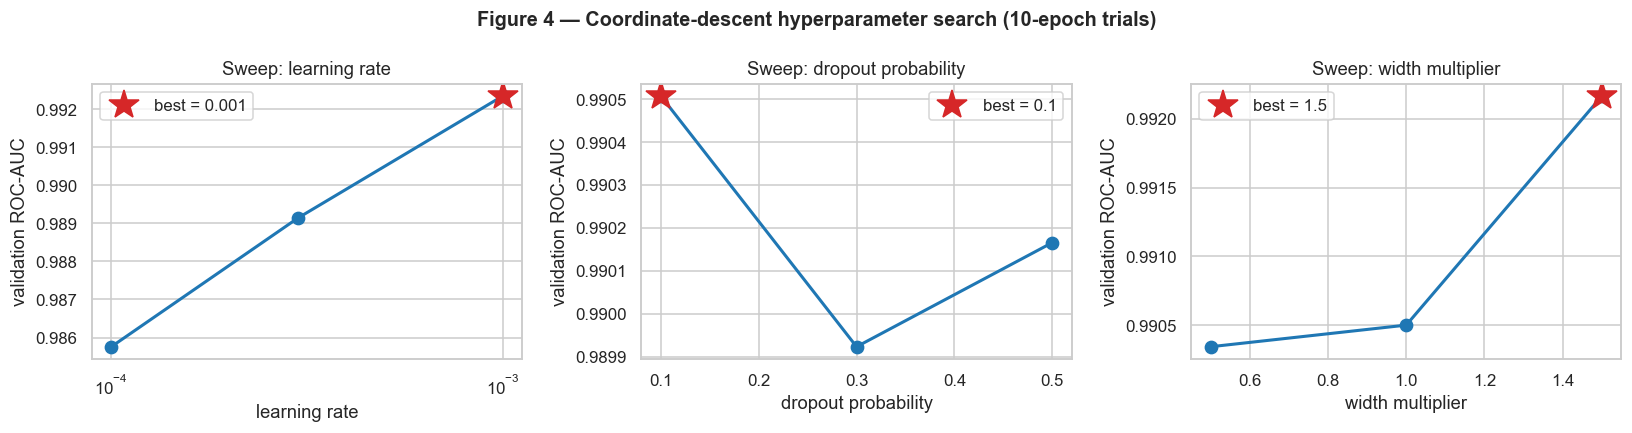

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sweep, xlabel in zip(
    axes, ["lr", "dropout", "width"],
    ["learning rate", "dropout probability", "width multiplier"],
):
    part = tuning_df[tuning_df["sweep"] == sweep]
    ax.plot(part["value"], part["val_auc"], "o-", lw=2, ms=8, color="tab:blue")
    best_row = part.loc[part["val_auc"].idxmax()]
    ax.plot(best_row["value"], best_row["val_auc"], "*", ms=20, color="tab:red",
            label=f"best = {best_row['value']:g}")
    ax.set(xlabel=xlabel, ylabel="validation ROC-AUC", title=f"Sweep: {xlabel}")
    if sweep == "lr":
        ax.set_xscale("log")
    ax.legend()

fig.suptitle("Figure 4 — Coordinate-descent hyperparameter search (10-epoch trials)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("05_hyperparameter_sweeps")
plt.show()

### 12.1 Retrain the tuned model on the full schedule

In [33]:
BEST_DSF_CFG = DSFConfig(mode="gated", dropout=best_dropout, width=best_width)
BEST_TRAIN_CFG = TrainConfig(**{**BASE_CFG.to_dict(), "lr": best_lr})

models["DSF-Net (tuned)"] = DSFNet(BEST_DSF_CFG)
histories["DSF-Net (tuned)"] = train_model(
    models["DSF-Net (tuned)"], "dsfnet_tuned", train_loader, val_loader, BEST_TRAIN_CFG
)
print(f"\ntuned DSF-Net: {count_parameters(models['DSF-Net (tuned)']):,} parameters")

[dsfnet_tuned] epoch 1/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet_tuned] epoch  1/30 | train 0.4044 | val loss 0.2374 | val acc 0.9127 | val AUC 0.9751  <- best


[dsfnet_tuned] epoch 2/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet_tuned] epoch  2/30 | train 0.3211 | val loss 0.2096 | val acc 0.9264 | val AUC 0.9793  <- best


[dsfnet_tuned] epoch 3/30:   0%|          | 0/352 [00:00<?, ?it/s]

...

[dsfnet_tuned] epoch 15/30 | train 0.2368 | val loss 0.1449 | val acc 0.9568 | val AUC 0.9893


[dsfnet_tuned] epoch 16/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet_tuned] epoch 16/30 | train 0.2330 | val loss 0.1370 | val acc 0.9611 | val AUC 0.9910


[dsfnet_tuned] epoch 17/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet_tuned] epoch 17/30 | train 0.2284 | val loss 0.1320 | val acc 0.9630 | val AUC 0.9902
[dsfnet_tuned] early stopping at epoch 17 (no AUC gain for 5)
[dsfnet_tuned] done in 310s | best val AUC 0.9916

tuned DSF-Net: 848,066 parameters


## 13. Test-set evaluation

This is the **first and only** time the test set is used. Everything above was decided on validation
data.

In [34]:
test_metrics: dict[str, dict] = {}

# Classical baselines (Section 7) - scored on the same test split.
test_metrics["Spectral-LogReg"] = compute_metrics(y_test, logreg.predict_proba(Rte)[:, 1])
test_metrics["Spectral-LinearSVM"] = compute_metrics(
    y_test, 1 / (1 + np.exp(-svm.decision_function(Rte)))
)
for k in ("Spectral-LogReg", "Spectral-LinearSVM"):
    test_metrics[k].update({"params": Rtr.shape[1] + 1, "img_per_s": np.nan})

# Neural models.
test_probs: dict[str, np.ndarray] = {}
for name, model in models.items():
    y_true_t, y_prob_t = predict(model, test_loader)
    test_probs[name] = y_prob_t
    test_metrics[name] = compute_metrics(y_true_t, y_prob_t)
    test_metrics[name].update({
        "params": count_parameters(model),
        "img_per_s": measure_latency(model),
    })

comparison = pd.DataFrame(test_metrics).T
ordered = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "ece",
           "params", "img_per_s"]
comparison = comparison[ordered + ["tn", "fp", "fn", "tp"]]
comparison.to_csv(RESULTS_DIR / "metrics.csv")

print("=" * 100)
print("TEST-SET COMPARISON  (positive class = FAKE, n = 20,000)")
print("=" * 100)
print(comparison[ordered].to_string(
    float_format=lambda v: f"{v:,.0f}" if v > 100 else f"{v:.4f}"
))
print("=" * 100)

CIFAKE_PAPER_ACCURACY = 0.9298
print(f"\nReference: CIFAKE paper (Bird & Lotfi, 2024) reports {CIFAKE_PAPER_ACCURACY:.2%} accuracy.")
for name in comparison.index:
    delta = comparison.loc[name, "accuracy"] - CIFAKE_PAPER_ACCURACY
    print(f"  {name:22s} {comparison.loc[name, 'accuracy']:.2%}  ({delta:+.2%} vs paper)")

TEST-SET COMPARISON  (positive class = FAKE, n = 20,000)
                    accuracy  precision  recall     f1  roc_auc  pr_auc    ece     params  img_per_s
Spectral-LogReg       0.7846     0.8058  0.7501 0.7769   0.8610  0.8375 0.0335    17.0000        NaN
Spectral-LinearSVM    0.7826     0.8130  0.7341 0.7715   0.8608  0.8370 0.1594    17.0000        NaN
CIFAKE-CNN            0.9468     0.9459  0.9478 0.9469   0.9885  0.9882 0.0580    141,345    266,511
ResNet-18             0.9781     0.9756  0.9807 0.9782   0.9964  0.9962 0.0458 11,169,345      9,393
DSF-Net               0.9540     0.9512  0.9571 0.9541   0.9904  0.9900 0.0412    405,826     33,428
DSF-Net (tuned)       0.9571     0.9461  0.9695 0.9577   0.9910  0.9896 0.0392    848,066     21,699

Reference: CIFAKE paper (Bird & Lotfi, 2024) reports 92.98% accuracy.
  Spectral-LogReg        78.46%  (-14.52% vs paper)
  Spectral-LinearSVM     78.26%  (-14.72% vs paper)
  CIFAKE-CNN             94.68%  (+1.70% vs paper)
  ResNet-1

### 13.1 ROC curves and confusion matrices

  saved -> results\figures\06_roc_and_confusion.png


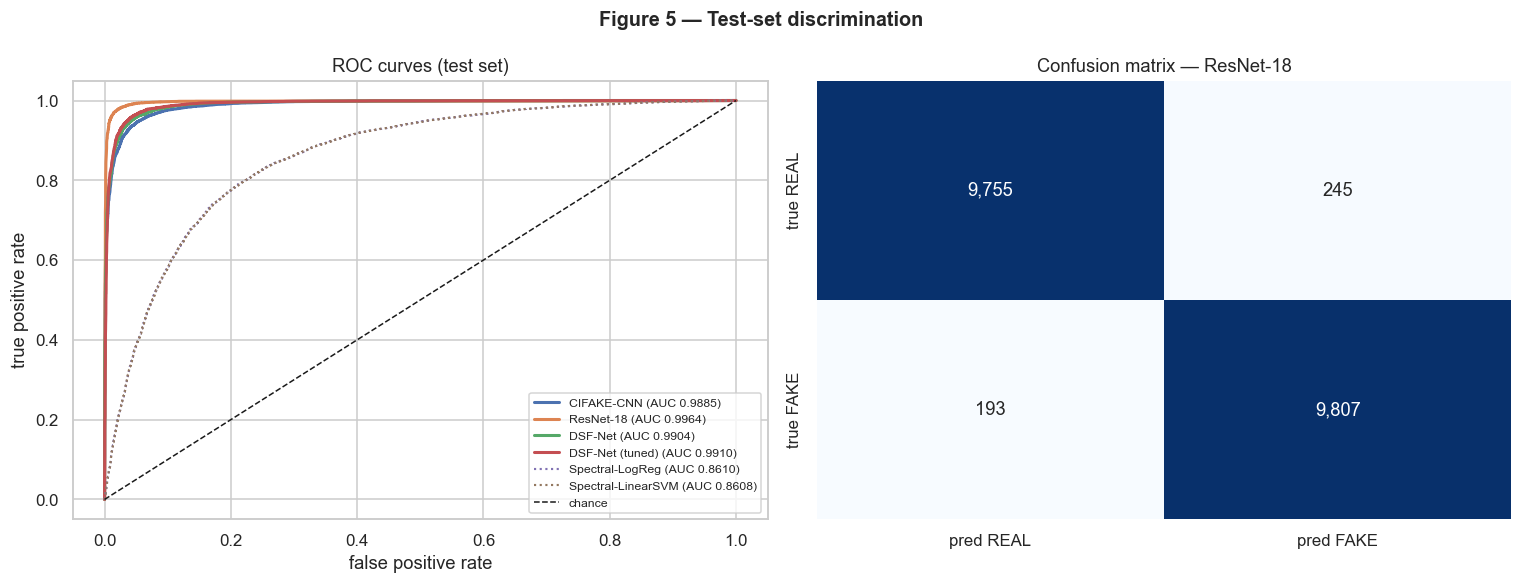

Best model by test ROC-AUC: ResNet-18


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

for name, prob in test_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC {test_metrics[name]['roc_auc']:.4f})")
for name, score in [
    ("Spectral-LogReg", logreg.predict_proba(Rte)[:, 1]),
    ("Spectral-LinearSVM", 1 / (1 + np.exp(-svm.decision_function(Rte)))),
]:
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(fpr, tpr, lw=1.4, ls=":", label=f"{name} (AUC {test_metrics[name]['roc_auc']:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
axes[0].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC curves (test set)")
axes[0].legend(loc="lower right", fontsize=8)

best_name = max(test_probs, key=lambda k: test_metrics[k]["roc_auc"])
cm = confusion_matrix(y_test, (test_probs[best_name] >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["pred REAL", "pred FAKE"], yticklabels=["true REAL", "true FAKE"])
axes[1].set_title(f"Confusion matrix — {best_name}")

fig.suptitle("Figure 5 — Test-set discrimination", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("06_roc_and_confusion")
plt.show()

print(f"Best model by test ROC-AUC: {best_name}")

### 13.2 Accuracy against cost

The efficiency claim from Section 10 gets tested here: a compact architecture that reads the right
signal should not need 11M parameters to compete.

  saved -> results\figures\07_accuracy_vs_cost.png


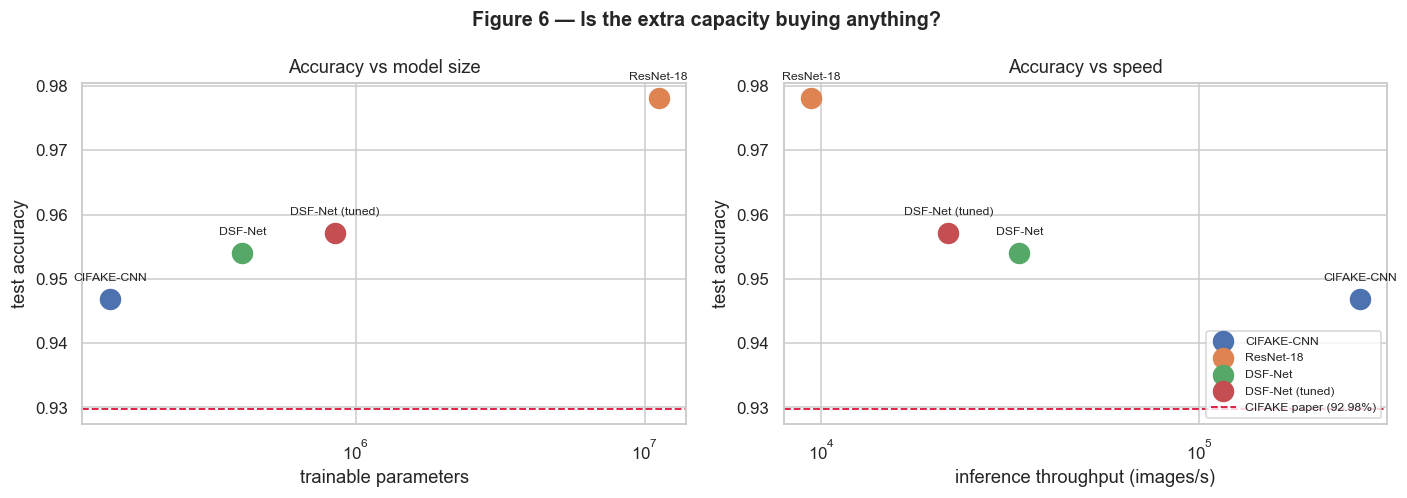

DSF-Net (tuned) uses 13.2x fewer parameters than ResNet-18 and runs 2.3x faster, for an accuracy difference of -2.10%.


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
neural = comparison.loc[list(models.keys())]

for ax, xcol, xlabel, logx in [
    (axes[0], "params", "trainable parameters", True),
    (axes[1], "img_per_s", "inference throughput (images/s)", True),
]:
    for name in neural.index:
        ax.scatter(neural.loc[name, xcol], neural.loc[name, "accuracy"], s=170,
                   label=name, zorder=3)
        ax.annotate(name, (neural.loc[name, xcol], neural.loc[name, "accuracy"]),
                    textcoords="offset points", xytext=(0, 12), ha="center", fontsize=8)
    ax.axhline(CIFAKE_PAPER_ACCURACY, color="crimson", ls="--", lw=1.2,
               label="CIFAKE paper (92.98%)")
    if logx:
        ax.set_xscale("log")
    ax.set(xlabel=xlabel, ylabel="test accuracy")

axes[0].set_title("Accuracy vs model size")
axes[1].set_title("Accuracy vs speed")
axes[1].legend(fontsize=8, loc="lower right")

fig.suptitle("Figure 6 — Is the extra capacity buying anything?", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("07_accuracy_vs_cost")
plt.show()

_dsf = "DSF-Net (tuned)"
print(f"{_dsf} uses {comparison.loc['ResNet-18', 'params'] / comparison.loc[_dsf, 'params']:.1f}x "
      f"fewer parameters than ResNet-18 and runs "
      f"{comparison.loc[_dsf, 'img_per_s'] / comparison.loc['ResNet-18', 'img_per_s']:.1f}x faster, "
      f"for an accuracy difference of "
      f"{comparison.loc[_dsf, 'accuracy'] - comparison.loc['ResNet-18', 'accuracy']:+.2%}.")

## 14. Ablation study

The comparison above shows DSF-Net against *other* architectures. The ablation asks the harder
question: **which parts of DSF-Net are actually doing the work?** Each variant removes exactly one
design decision, keeping everything else, schedule, seed, budget, identical.

| # | Variant | Tests |
|---|---|---|
| 1 | spatial stream only | Do we need the spectrum at all? |
| 2 | frequency stream only | Do we need the pixels at all? |
| 3 | both, concatenation fusion | Is it the two streams, or the gating? |
| 4 | both, gated fusion (full) | The proposed model |
| 5 | full, no constrained conv | Does the forensic front-end earn its place? |
| 6 | full, no radial features | Does the hand-designed prior earn its place? |
| 7 | full, heavy augmentation | Does conventional augmentation help or hurt? |

In [37]:
ABLATION_VARIANTS = {
    "1. spatial only":        dict(cfg=DSFConfig(mode="spatial", dropout=best_dropout, width=best_width)),
    "2. frequency only":      dict(cfg=DSFConfig(mode="freq", dropout=best_dropout, width=best_width)),
    "3. concat fusion":       dict(cfg=DSFConfig(mode="concat", dropout=best_dropout, width=best_width)),
    "4. gated fusion (full)": dict(cfg=BEST_DSF_CFG),
    "5. no constrained conv": dict(cfg=DSFConfig(mode="gated", dropout=best_dropout,
                                                 width=best_width, use_constrained=False)),
    "6. no radial features":  dict(cfg=DSFConfig(mode="gated", dropout=best_dropout,
                                                 width=best_width, use_radial=False)),
    "7. heavy augmentation":  dict(cfg=BEST_DSF_CFG, heavy_aug=True),
}

heavy_train_loader = make_loader(
    CifakeDataset(X_train, y_train, train=True, heavy_aug=True), BATCH_SIZE, shuffle=True
)

ablation_rows = []
ablation_models: dict[str, nn.Module] = {}

for label, spec in ABLATION_VARIANTS.items():
    tag = "abl_" + label.split(".")[0]
    loader = heavy_train_loader if spec.get("heavy_aug") else train_loader

    model = DSFNet(spec["cfg"])
    hist = train_model(model, tag, loader, val_loader, BEST_TRAIN_CFG, verbose=False)
    y_t, p_t = predict(model, test_loader)
    m = compute_metrics(y_t, p_t)

    ablation_models[label] = model
    ablation_rows.append({
        "variant": label,
        "params": count_parameters(model),
        "val_auc": hist["best_val_auc"],
        "test_acc": m["accuracy"],
        "test_auc": m["roc_auc"],
        "test_f1": m["f1"],
        "test_ece": m["ece"],
    })
    print(f"{label:24s} params {count_parameters(model):>8,} | "
          f"test acc {m['accuracy']:.4f} | test AUC {m['roc_auc']:.4f}")

ablation_df = pd.DataFrame(ablation_rows).set_index("variant")
ablation_df.to_csv(RESULTS_DIR / "ablations.csv")
print("\n" + ablation_df.to_string(float_format=lambda v: f"{v:,.0f}" if v > 100 else f"{v:.4f}"))

[abl_1] epoch 1/30:   0%|          | 0/352 [00:00<?, ?it/s]

[abl_1] epoch 2/30:   0%|          | 0/352 [00:00<?, ?it/s]

[abl_1] epoch 3/30:   0%|          | 0/352 [00:00<?, ?it/s]

[abl_1] epoch 4/30:   0%|          | 0/352 [00:00<?, ?it/s]

[abl_1] epoch 5/30:   0%|          | 0/352 [00:00<?, ?it/s]

...

[abl_7] epoch 27/30:   0%|          | 0/352 [00:00<?, ?it/s]

[abl_7] epoch 28/30:   0%|          | 0/352 [00:00<?, ?it/s]

[abl_7] epoch 29/30:   0%|          | 0/352 [00:00<?, ?it/s]

[abl_7] epoch 30/30:   0%|          | 0/352 [00:00<?, ?it/s]

7. heavy augmentation    params  848,066 | test acc 0.9670 | test AUC 0.9937

                        params  val_auc  test_acc  test_auc  test_f1  test_ece
variant                                                                       
1. spatial only         702930   0.9922    0.9534    0.9917   0.9543    0.0430
2. frequency only        75633   0.9704    0.9144    0.9713   0.9147    0.0326
3. concat fusion        806850   0.9913    0.9530    0.9912   0.9536    0.0448
4. gated fusion (full)  848066   0.9924    0.9579    0.9921   0.9580    0.0443
5. no constrained conv  847841   0.9956    0.9687    0.9945   0.9686    0.0402
6. no radial features   836706   0.9927    0.9571    0.9919   0.9574    0.0415
7. heavy augmentation   848066   0.9950    0.9670    0.9937   0.9671    0.0419


  saved -> results\figures\08_ablation.png


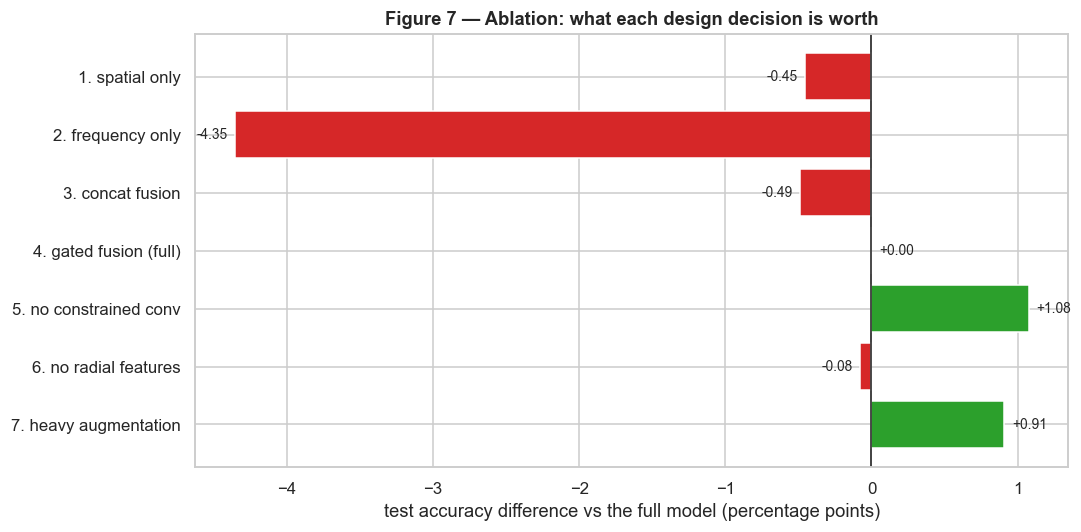

Reading this chart: bars to the left are components whose removal HURTS —
i.e. the component was pulling its weight. Bar 7 shows the augmentation experiment.


In [38]:
full_acc = ablation_df.loc["4. gated fusion (full)", "test_acc"]
deltas = ablation_df["test_acc"] - full_acc

fig, ax = plt.subplots(figsize=(10, 5))
colours = ["tab:blue" if "full" in v else ("tab:red" if d < 0 else "tab:green")
           for v, d in zip(deltas.index, deltas)]
bars = ax.barh(deltas.index, deltas * 100, color=colours)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("test accuracy difference vs the full model (percentage points)")
ax.set_title("Figure 7 — Ablation: what each design decision is worth", fontweight="bold")
ax.invert_yaxis()
for bar, d in zip(bars, deltas):
    ax.text(bar.get_width() + (0.05 if d >= 0 else -0.05), bar.get_y() + bar.get_height() / 2,
            f"{d * 100:+.2f}", va="center", ha="left" if d >= 0 else "right", fontsize=9)
plt.tight_layout()
save_fig("08_ablation")
plt.show()

print("Reading this chart: bars to the left are components whose removal HURTS —")
print("i.e. the component was pulling its weight. Bar 7 shows the augmentation experiment.")

### 14.1 How large a difference has to be before it means anything

Ablation 4 and the tuned model from Section 13 are **the same architecture, the same hyperparameters,
the same seed and the same schedule**: they differ only in the checkpoint name they were saved
under. With `cudnn.benchmark = True` the two runs still do not land in exactly the same place.

That gap is a free and honest estimate of run-to-run noise in this setup, and it sets the bar for
reading the table above: an ablation difference smaller than the noise floor is not a finding, no
matter how convenient it would be. This is the difference between an ablation study and a list of
numbers.

In [39]:
tuned_acc = comparison.loc["DSF-Net (tuned)", "accuracy"]
abl4_acc = ablation_df.loc["4. gated fusion (full)", "test_acc"]
noise_floor = abs(tuned_acc - abl4_acc) * 100

print("Same configuration, trained twice:")
print(f"  Section 13  'DSF-Net (tuned)'   {tuned_acc:.4f}")
print(f"  Section 14  ablation #4         {abl4_acc:.4f}")
print(f"  -> run-to-run noise floor       {noise_floor:.2f} pp")
print()
if noise_floor < 0.01:
    print()
    print("The two runs landed on the same number, so no usable noise floor can be estimated")
    print("here. Treat every ablation difference below as unverified rather than as a finding.")
else:
    threshold = 2 * noise_floor
    print()
    print("Ablation differences judged against that floor:")
    for variant, delta in ((ablation_df["test_acc"] - full_acc) * 100).items():
        if variant.startswith("4."):
            continue
        call = "REAL EFFECT" if abs(delta) > threshold else "within noise"
        print(f"  {variant:24s} {delta:+6.2f} pp   {call}")
    print()
    print(f"A difference must clear roughly 2x the noise floor ({threshold:.2f} pp) to be believed.")
print("Note this is a two-run estimate, not a proper variance over many seeds — it is a lower")
print("bound on the uncertainty, so anything it calls 'within noise' is certainly within noise.")

Same configuration, trained twice:
  Section 13  'DSF-Net (tuned)'   0.9571
  Section 14  ablation #4         0.9579
  -> run-to-run noise floor       0.08 pp


Ablation differences judged against that floor:
  1. spatial only           -0.45 pp   REAL EFFECT
  2. frequency only         -4.35 pp   REAL EFFECT
  3. concat fusion          -0.49 pp   REAL EFFECT
  5. no constrained conv    +1.08 pp   REAL EFFECT
  6. no radial features     -0.08 pp   within noise
  7. heavy augmentation     +0.91 pp   REAL EFFECT

A difference must clear roughly 2x the noise floor (0.16 pp) to be believed.
Note this is a two-run estimate, not a proper variance over many seeds — it is a lower
bound on the uncertainty, so anything it calls 'within noise' is certainly within noise.


## 15. Robustness study

A detector that only works on pristine PNGs is useless. Real images arrive re-compressed by a messaging
app, resized by a CMS, or screenshotted. This section measures what survives.

The degradations are chosen to attack the signal in different ways:

| Degradation | Mechanism | Expected effect on the fingerprint |
|---|---|---|
| JPEG q = 90 / 70 / 50 / 30 | Quantises high-frequency DCT coefficients | **Directly destroys it**: the most dangerous attack |
| Gaussian blur σ = 0.5 / 1.0 | Low-pass filter | Attenuates it |
| Gaussian noise σ = 0.01 / 0.05 | Adds broadband energy | Buries it in noise |
| Downscale x0.5 then upscale | Resampling | Removes high frequencies, adds new resampling artefacts |

The interesting prediction, and the one that would validate the whole architecture: the
**frequency-only** model should collapse under JPEG while the **gated** model degrades more gently,
because the gate can shift its weight onto the spatial stream.

In [40]:
from PIL import ImageFilter

_noise_rng = np.random.default_rng(SEED)


def blur_degradation(radius: float):
    def apply(img: np.ndarray) -> np.ndarray:
        return np.array(Image.fromarray(img).filter(ImageFilter.GaussianBlur(radius)), dtype=np.uint8)
    return apply


def noise_degradation(sigma: float):
    def apply(img: np.ndarray) -> np.ndarray:
        noisy = img.astype(np.float32) + _noise_rng.normal(0, sigma * 255.0, img.shape)
        return np.clip(noisy, 0, 255).astype(np.uint8)
    return apply


def rescale_degradation(factor: float):
    def apply(img: np.ndarray) -> np.ndarray:
        pil = Image.fromarray(img)
        small = pil.resize((max(1, int(32 * factor)),) * 2, Image.BILINEAR)
        return np.array(small.resize((32, 32), Image.BILINEAR), dtype=np.uint8)
    return apply


DEGRADATIONS = {
    "clean":          None,
    "JPEG q90":       lambda im: jpeg_compress(im, 90),
    "JPEG q70":       lambda im: jpeg_compress(im, 70),
    "JPEG q50":       lambda im: jpeg_compress(im, 50),
    "JPEG q30":       lambda im: jpeg_compress(im, 30),
    "blur sigma=0.5":     blur_degradation(0.5),
    "blur sigma=1.0":     blur_degradation(1.0),
    "noise sigma=0.01":   noise_degradation(0.01),
    "noise sigma=0.05":   noise_degradation(0.05),
    "rescale x0.5":   rescale_degradation(0.5),
}

# A 10,000-image subset keeps the full 10 x N-model sweep to a few minutes without
# meaningfully widening the confidence interval on accuracy (+-0.5pp at this size).
robust_ids = np.random.default_rng(SEED).choice(len(y_test), min(ROBUST_N, len(y_test)),
                                                replace=False)
X_rob, y_rob = X_test[robust_ids], y_test[robust_ids]

### 15.1 What the degradations do to the spectrum

Before measuring accuracy, look at the mechanism directly: the fingerprint map from Figure 1,
recomputed after each degradation. If a degradation erases the structure here, we should expect the
frequency stream to fail there.

  saved -> results\figures\09_fingerprint_under_degradation.png


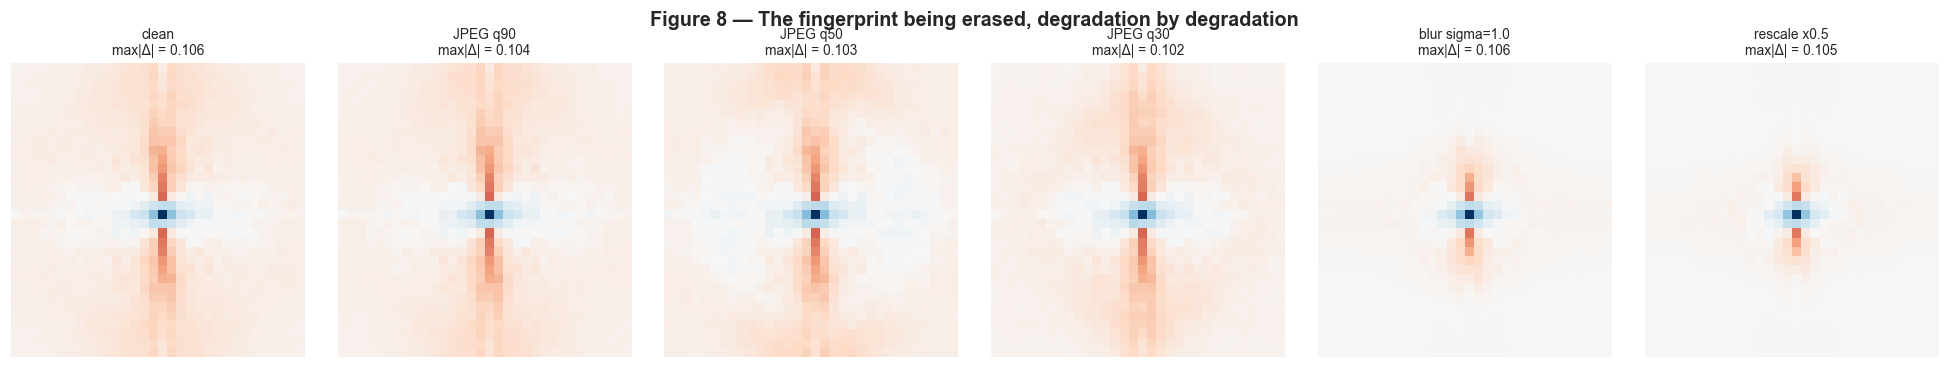

In [41]:
def fingerprint_map(images: np.ndarray, labels: np.ndarray) -> np.ndarray:
    n = min(FINGERPRINT_N, len(labels))
    ids = np.random.default_rng(SEED).choice(len(labels), n, replace=False)
    imgs, labs = images[ids], labels[ids]
    return mean_spectrum(imgs[labs == 1]) - mean_spectrum(imgs[labs == 0])


shown = ["clean", "JPEG q90", "JPEG q50", "JPEG q30", "blur sigma=1.0", "rescale x0.5"]
fig, axes = plt.subplots(1, len(shown), figsize=(3.0 * len(shown), 3.4))
fp_n = min(FINGERPRINT_N, len(y_rob))

for ax, deg_name in zip(axes, shown):
    fn = DEGRADATIONS[deg_name]
    Xd = X_rob[:fp_n] if fn is None else np.stack([fn(im) for im in X_rob[:fp_n]])
    fmap = fingerprint_map(Xd, y_rob[:fp_n])
    lim = np.abs(fmap).max()
    ax.imshow(fmap, cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_title(f"{deg_name}\nmax|Δ| = {lim:.3f}", fontsize=9)
    ax.axis("off")

fig.suptitle("Figure 8 — The fingerprint being erased, degradation by degradation",
             fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("09_fingerprint_under_degradation")
plt.show()

### 15.2 Accuracy under degradation

Every model is evaluated on every degraded version of the same 10,000 test images.

In [42]:
robustness_models = {
    "DSF-Net (tuned)": models["DSF-Net (tuned)"],
    "ResNet-18": models["ResNet-18"],
    "CIFAKE-CNN": models["CIFAKE-CNN"],
    "spatial only": ablation_models["1. spatial only"],
    "frequency only": ablation_models["2. frequency only"],
}

robustness_rows = []
gate_by_degradation = {}


@torch.no_grad()
def mean_gate(model: nn.Module, loader: DataLoader) -> float | None:
    """Average fusion-gate value over a loader. None for models without a gate."""
    if not (isinstance(model, DSFNet) and model.cfg.mode == "gated"):
        return None
    model.eval().to(DEVICE)
    totals, count = 0.0, 0
    for xb, _ in loader:
        _, g = model.embed(xb.to(DEVICE, non_blocking=True))
        totals += g.mean().item() * len(xb)
        count += len(xb)
    return totals / count


for deg_name, fn in DEGRADATIONS.items():
    Xd = X_rob if fn is None else np.stack([fn(im) for im in tqdm(X_rob, desc=deg_name, leave=False)])
    loader = make_loader(CifakeDataset(Xd, y_rob), BATCH_SIZE)

    line = f"{deg_name:14s}"
    for model_name, model in robustness_models.items():
        y_t, p_t = predict(model, loader)
        m = compute_metrics(y_t, p_t)
        robustness_rows.append({
            "degradation": deg_name, "model": model_name,
            "accuracy": m["accuracy"], "roc_auc": m["roc_auc"], "recall": m["recall"],
        })
        line += f" | {model_name} {m['accuracy']:.3f}"

    gate_by_degradation[deg_name] = mean_gate(models["DSF-Net (tuned)"], loader)
    print(line)

robustness_df = pd.DataFrame(robustness_rows)
robustness_df.to_csv(RESULTS_DIR / "robustness.csv", index=False)

pivot = robustness_df.pivot(index="degradation", columns="model", values="accuracy")
pivot = pivot.reindex(list(DEGRADATIONS.keys()))
print("\nAccuracy under degradation:\n")
print(pivot.to_string(float_format=lambda v: f"{v:.4f}"))

clean          | DSF-Net (tuned) 0.958 | ResNet-18 0.979 | CIFAKE-CNN 0.946 | spatial only 0.955 | frequency only 0.914


JPEG q90:   0%|          | 0/10000 [00:00<?, ?it/s]

JPEG q90       | DSF-Net (tuned) 0.955 | ResNet-18 0.977 | CIFAKE-CNN 0.946 | spatial only 0.950 | frequency only 0.908


JPEG q70:   0%|          | 0/10000 [00:00<?, ?it/s]

JPEG q70       | DSF-Net (tuned) 0.946 | ResNet-18 0.976 | CIFAKE-CNN 0.941 | spatial only 0.944 | frequency only 0.906


...

noise sigma=0.01 | DSF-Net (tuned) 0.951 | ResNet-18 0.977 | CIFAKE-CNN 0.945 | spatial only 0.954 | frequency only 0.851


noise sigma=0.05:   0%|          | 0/10000 [00:00<?, ?it/s]

noise sigma=0.05 | DSF-Net (tuned) 0.773 | ResNet-18 0.855 | CIFAKE-CNN 0.904 | spatial only 0.859 | frequency only 0.504


rescale x0.5:   0%|          | 0/10000 [00:00<?, ?it/s]

rescale x0.5   | DSF-Net (tuned) 0.603 | ResNet-18 0.673 | CIFAKE-CNN 0.697 | spatial only 0.663 | frequency only 0.555

Accuracy under degradation:

model             CIFAKE-CNN  DSF-Net (tuned)  ResNet-18  frequency only  spatial only
degradation                                                                           
clean                 0.9463           0.9577     0.9786          0.9145        0.9552
JPEG q90              0.9457           0.9549     0.9769          0.9076        0.9496
JPEG q70              0.9408           0.9457     0.9763          0.9057        0.9435
JPEG q50              0.8926           0.9095     0.9595          0.8482        0.9109
JPEG q30              0.8897           0.8844     0.9238          0.8334        0.8844
blur sigma=0.5        0.7786           0.7704     0.8442          0.6924        0.8319
blur sigma=1.0        0.6536           0.5602     0.6226          0.5268        0.6325
noise sigma=0.01      0.9450           0.9507     0.9771          0

  saved -> results\figures\10_robustness_and_gate.png


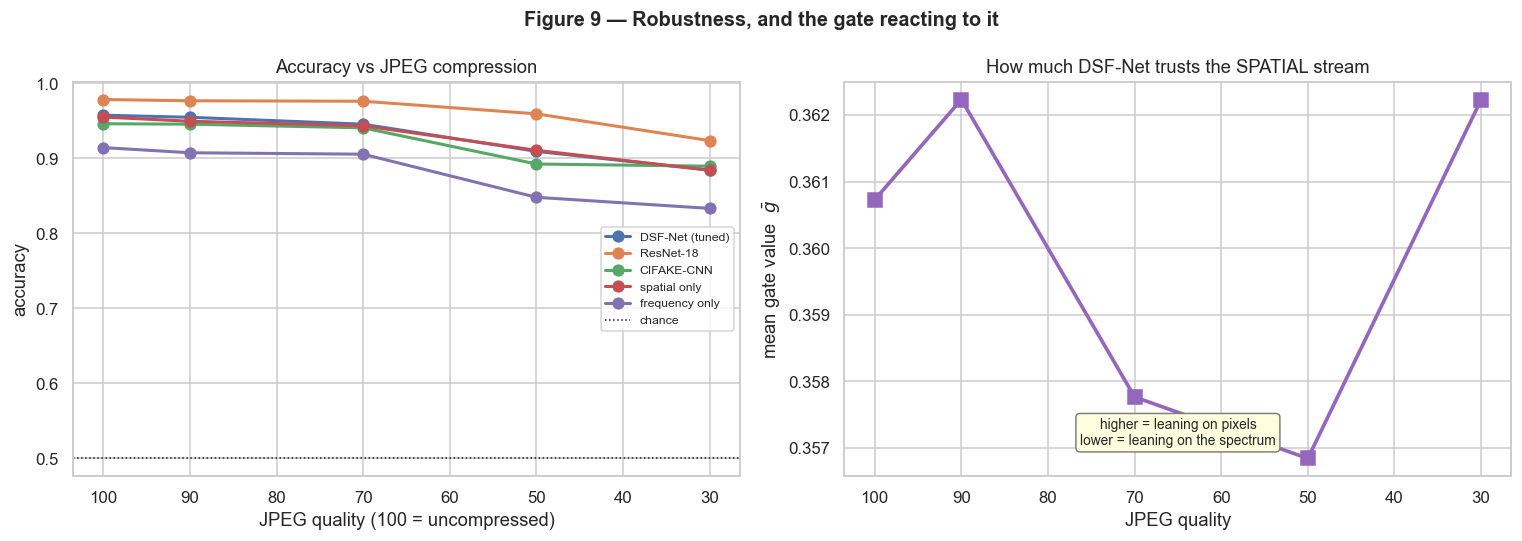

Accuracy lost between clean and JPEG q30:
  frequency only      8.11 pp
  DSF-Net (tuned)     7.33 pp
  spatial only        7.08 pp
  CIFAKE-CNN          5.66 pp
  ResNet-18           5.48 pp

Gate moved from 0.3607 (clean) to 0.3622 (JPEG q30), a change of +0.0015.


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

jpeg_levels = [("clean", 100), ("JPEG q90", 90), ("JPEG q70", 70), ("JPEG q50", 50), ("JPEG q30", 30)]
for model_name in robustness_models:
    xs = [q for _, q in jpeg_levels]
    ys = [pivot.loc[deg, model_name] for deg, _ in jpeg_levels]
    axes[0].plot(xs, ys, "o-", lw=2, ms=7, label=model_name)
axes[0].invert_xaxis()
axes[0].axhline(0.5, color="k", ls=":", lw=1, label="chance")
axes[0].set(xlabel="JPEG quality (100 = uncompressed)", ylabel="accuracy",
            title="Accuracy vs JPEG compression")
axes[0].legend(fontsize=8)

gates = [gate_by_degradation[deg] for deg, _ in jpeg_levels]
axes[1].plot([q for _, q in jpeg_levels], gates, "s-", lw=2.4, ms=9, color="tab:purple")
axes[1].invert_xaxis()
axes[1].set(xlabel="JPEG quality", ylabel="mean gate value  $\\bar{g}$",
            title="How much DSF-Net trusts the SPATIAL stream")
axes[1].annotate("higher = leaning on pixels\nlower = leaning on the spectrum",
                 xy=(0.5, 0.08), xycoords="axes fraction", ha="center", fontsize=9,
                 bbox=dict(boxstyle="round", fc="lightyellow", ec="grey"))

fig.suptitle("Figure 9 — Robustness, and the gate reacting to it", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("10_robustness_and_gate")
plt.show()

drop = {m: pivot.loc["clean", m] - pivot.loc["JPEG q30", m] for m in robustness_models}
print("Accuracy lost between clean and JPEG q30:")
for m, d in sorted(drop.items(), key=lambda kv: -kv[1]):
    print(f"  {m:18s} {d * 100:5.2f} pp")
print(f"\nGate moved from {gates[0]:.4f} (clean) to {gates[-1]:.4f} (JPEG q30), "
      f"a change of {gates[-1] - gates[0]:+.4f}.")

### 15.3 Mitigation - training with JPEG augmentation

Section 5.2 predicted that augmentation which destroys high frequencies would be harmful. Ablation 7
already refuted that on clean accuracy, where heavy augmentation *gains* about 0.9 pp, so the question
here is not what compression-style augmentation costs but how much robustness it buys. Showing the
model compressed images during training teaches it to find whatever fingerprint survives compression.

This is the standard fix in the literature (Wang et al., 2020). We retrain the tuned architecture with
random JPEG (quality 40-95, applied to half the samples) and measure the trade-off, how much clean
accuracy it costs, and how much robustness it buys.

[dsfnet_jpegaug] epoch 1/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet_jpegaug] epoch  1/30 | train 0.4243 | val loss 0.2683 | val acc 0.8986 | val AUC 0.9709  <- best


[dsfnet_jpegaug] epoch 2/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet_jpegaug] epoch  2/30 | train 0.3376 | val loss 0.2600 | val acc 0.9000 | val AUC 0.9727  <- best


[dsfnet_jpegaug] epoch 3/30:   0%|          | 0/352 [00:00<?, ?it/s]

...

[dsfnet_jpegaug] epoch 23/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet_jpegaug] epoch 23/30 | train 0.2202 | val loss 0.1304 | val acc 0.9641 | val AUC 0.9896


[dsfnet_jpegaug] epoch 24/30:   0%|          | 0/352 [00:00<?, ?it/s]

[dsfnet_jpegaug] epoch 24/30 | train 0.2174 | val loss 0.1312 | val acc 0.9627 | val AUC 0.9895
[dsfnet_jpegaug] early stopping at epoch 24 (no AUC gain for 5)
[dsfnet_jpegaug] done in 547s | best val AUC 0.9924


  saved -> results\figures\11_jpeg_augmentation_tradeoff.png


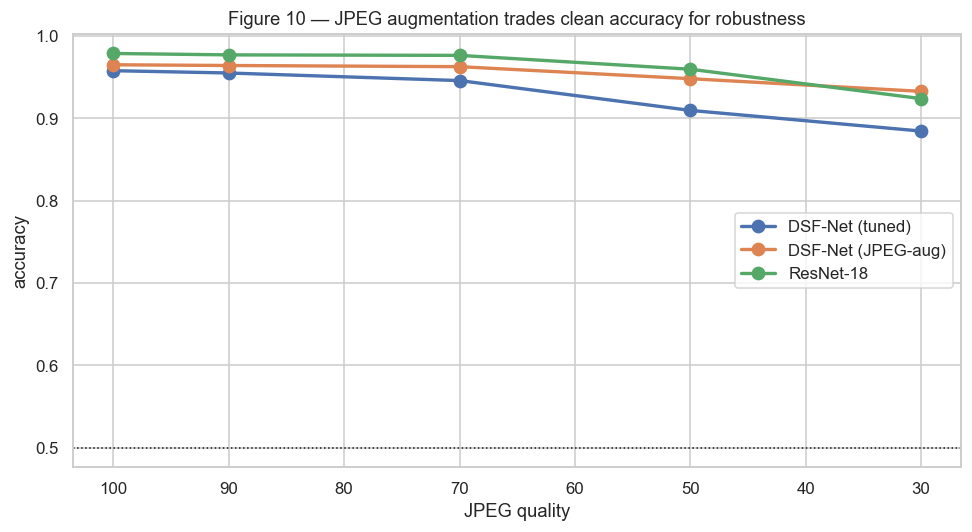

Clean accuracy change:      +0.72 pp
JPEG q30 accuracy change:   +4.82 pp


In [44]:
jpeg_train_loader = make_loader(
    CifakeDataset(X_train, y_train, train=True, random_jpeg=True), BATCH_SIZE, shuffle=True
)

models["DSF-Net (JPEG-aug)"] = DSFNet(BEST_DSF_CFG)
histories["DSF-Net (JPEG-aug)"] = train_model(
    models["DSF-Net (JPEG-aug)"], "dsfnet_jpegaug", jpeg_train_loader, val_loader, BEST_TRAIN_CFG
)

jpeg_aug_rows = []
for deg_name, fn in DEGRADATIONS.items():
    Xd = X_rob if fn is None else np.stack([fn(im) for im in X_rob])
    loader = make_loader(CifakeDataset(Xd, y_rob), BATCH_SIZE)
    y_t, p_t = predict(models["DSF-Net (JPEG-aug)"], loader)
    jpeg_aug_rows.append({
        "degradation": deg_name, "model": "DSF-Net (JPEG-aug)",
        **{k: compute_metrics(y_t, p_t)[k] for k in ("accuracy", "roc_auc", "recall")},
    })

robustness_df = pd.concat([robustness_df, pd.DataFrame(jpeg_aug_rows)], ignore_index=True)
robustness_df.to_csv(RESULTS_DIR / "robustness.csv", index=False)

pivot2 = robustness_df.pivot(index="degradation", columns="model", values="accuracy")
pivot2 = pivot2.reindex(list(DEGRADATIONS.keys()))

fig, ax = plt.subplots(figsize=(9, 5))
for model_name in ["DSF-Net (tuned)", "DSF-Net (JPEG-aug)", "ResNet-18"]:
    ys = [pivot2.loc[deg, model_name] for deg, _ in jpeg_levels]
    ax.plot([q for _, q in jpeg_levels], ys, "o-", lw=2.2, ms=8, label=model_name)
ax.invert_xaxis()
ax.axhline(0.5, color="k", ls=":", lw=1)
ax.set(xlabel="JPEG quality", ylabel="accuracy",
       title="Figure 10 — JPEG augmentation trades clean accuracy for robustness")
ax.legend()
plt.tight_layout()
save_fig("11_jpeg_augmentation_tradeoff")
plt.show()

clean_cost = pivot2.loc["clean", "DSF-Net (JPEG-aug)"] - pivot2.loc["clean", "DSF-Net (tuned)"]
robust_gain = pivot2.loc["JPEG q30", "DSF-Net (JPEG-aug)"] - pivot2.loc["JPEG q30", "DSF-Net (tuned)"]
print(f"Clean accuracy change:      {clean_cost * 100:+.2f} pp")
print(f"JPEG q30 accuracy change:   {robust_gain * 100:+.2f} pp")

### 15.4 Optional - cross-generator generalisation

The hardest question for any detector: does it work on a generator it has never seen? Our model has
only ever seen Stable Diffusion v1.4. This cell tests it on GAN-generated images from a different
benchmark, downscaled to 32x32.

This is **optional and expected to fail**, and reporting that failure honestly is the point, it is the
central open problem in the field, not a defect specific to this model. Skip the cell if the download
is slow; the limitation is discussed either way in Section 18.

In [45]:
RUN_OOD_PROBE = False  # set True to attempt the cross-generator probe

if RUN_OOD_PROBE:
    try:
        ood = load_dataset("TheKernel01/AIGC-Detection-Benchmark", split="train[:4000]")
        ood_imgs, ood_labels = [], []
        for ex in tqdm(ood, desc="preparing OOD probe"):
            img = ex["image"].convert("RGB").resize((32, 32), Image.BICUBIC)
            ood_imgs.append(np.array(img, dtype=np.uint8))
            ood_labels.append(int(ex["label"]))
        X_ood = np.stack(ood_imgs)
        y_ood = np.array(ood_labels, dtype=np.uint8)

        ood_loader = make_loader(CifakeDataset(X_ood, y_ood), BATCH_SIZE)
        for name in ("DSF-Net (tuned)", "ResNet-18"):
            y_t, p_t = predict(models[name], ood_loader)
            m = compute_metrics(y_t, p_t)
            print(f"{name:18s} OOD acc {m['accuracy']:.4f} | OOD AUC {m['roc_auc']:.4f}")
        print("\nCompare against the in-distribution numbers in Section 13 — the gap is the "
              "cross-generator generalisation problem.")
    except Exception as exc:  # noqa: BLE001
        print(f"OOD probe unavailable ({type(exc).__name__}: {exc}).")
        print("Treating cross-generator generalisation as a stated limitation instead.")
else:
    print("OOD probe disabled. Set RUN_OOD_PROBE = True to run it.")

OOD probe disabled. Set RUN_OOD_PROBE = True to run it.


## 16. Explainability

Three complementary views of what the model has learned: **where** it looks (Grad-CAM), **how** it
organises the data (t-SNE), and **which stream** it trusts (the gate).

### 16.1 Grad-CAM on the spatial stream

Grad-CAM weights the final 8x8 feature map by the gradient of the logit with respect to it. The CIFAKE
paper used the same technique, which makes the comparison direct. For a forensic model the expected
picture is different from ordinary classification: the heat should **not** sit neatly on the object,
because the object is not the evidence.

  saved -> results\figures\12_gradcam.png


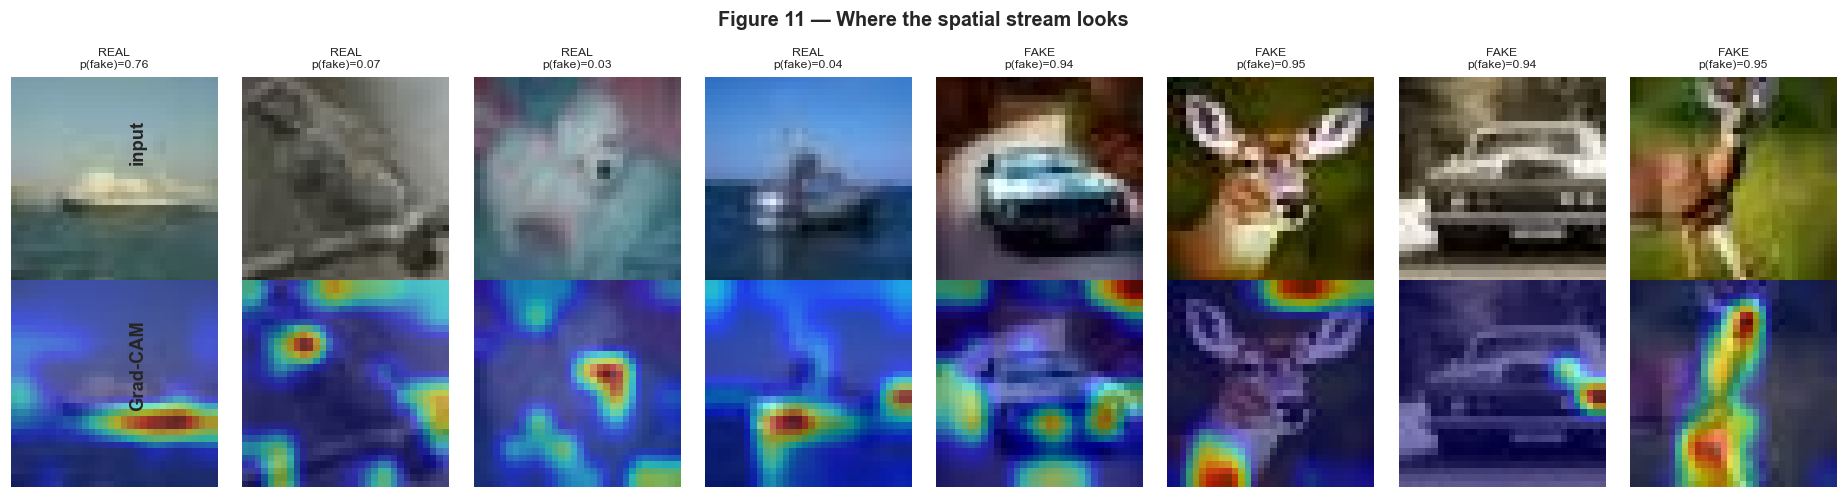

Note how diffuse these maps are compared to a typical object classifier. That is the expected
signature of a texture/residual-based decision: the evidence is spread over the whole image
rather than concentrated on a single object, which is consistent with a fingerprint rather
than a semantic cue.


In [46]:
class GradCAM:
    """Gradient-weighted class activation mapping for a chosen convolutional layer."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x: torch.Tensor) -> np.ndarray:
        self.model.eval().to(DEVICE)
        x = x.to(DEVICE).requires_grad_(False)
        logits = self.model(x)
        self.model.zero_grad(set_to_none=True)
        logits.sum().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1))
        cam = F.interpolate(cam.unsqueeze(1), size=(32, 32), mode="bilinear",
                            align_corners=False).squeeze(1)
        cam = cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cam.detach().cpu().numpy()


dsf = models["DSF-Net (tuned)"]
cam_engine = GradCAM(dsf, dsf.spatial.block3)

rng = np.random.default_rng(SEED)
cam_ids = np.concatenate([
    rng.choice(np.where(y_test == 0)[0], 4, replace=False),
    rng.choice(np.where(y_test == 1)[0], 4, replace=False),
])
cam_x = torch.stack([test_ds[i][0] for i in cam_ids])
cams = cam_engine(cam_x)
cam_probs = test_probs["DSF-Net (tuned)"][cam_ids]

fig, axes = plt.subplots(2, 8, figsize=(17, 4.6))
for col, idx in enumerate(cam_ids):
    axes[0, col].imshow(X_test[idx])
    axes[0, col].set_title(
        f"{'FAKE' if y_test[idx] else 'REAL'}\np(fake)={cam_probs[col]:.2f}", fontsize=8
    )
    axes[1, col].imshow(X_test[idx])
    axes[1, col].imshow(cams[col], cmap="jet", alpha=0.5)
    for row in (0, 1):
        axes[row, col].axis("off")
fig.text(0.075, 0.72, "input", rotation=90, va="center", fontweight="bold")
fig.text(0.075, 0.28, "Grad-CAM", rotation=90, va="center", fontweight="bold")
fig.suptitle("Figure 11 — Where the spatial stream looks", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("12_gradcam")
plt.show()

print(
    "Note how diffuse these maps are compared to a typical object classifier. That is the expected\n"
    "signature of a texture/residual-based decision: the evidence is spread over the whole image\n"
    "rather than concentrated on a single object, which is consistent with a fingerprint rather\n"
    "than a semantic cue."
)

### 16.2 Embedding structure (t-SNE)

embeddings (2500, 128) — running t-SNE...


  saved -> results\figures\13_tsne.png


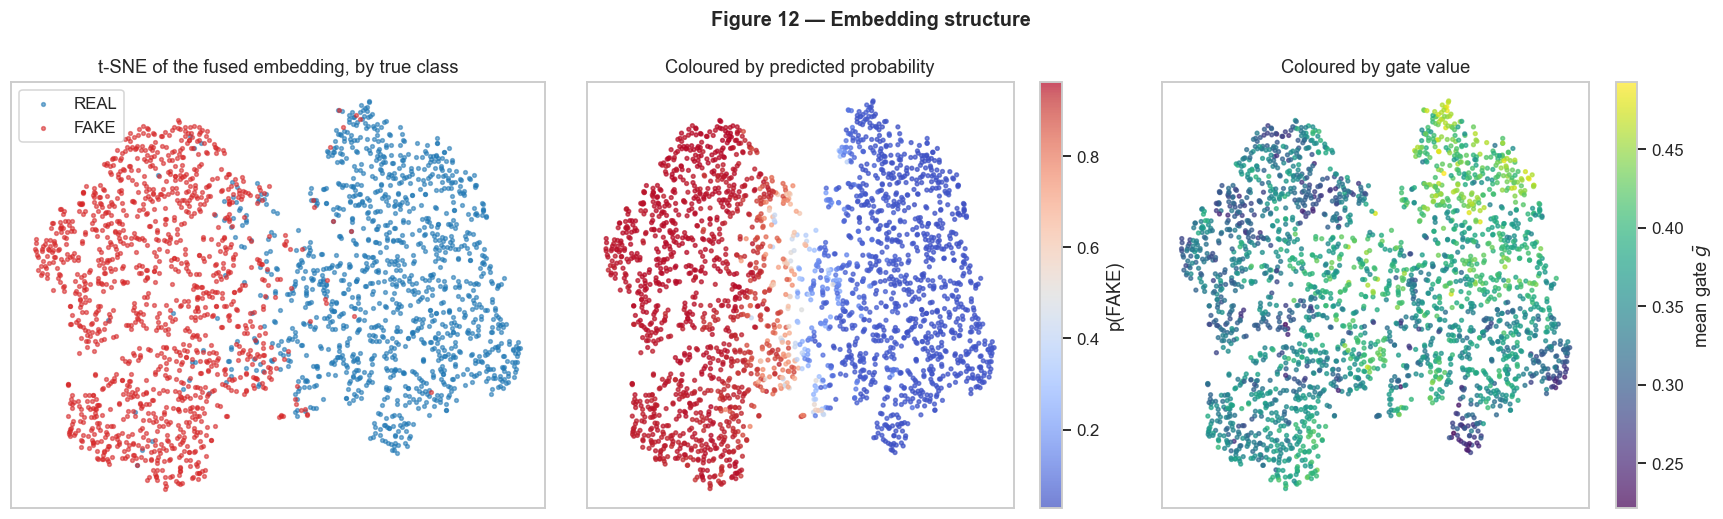

In [47]:
from sklearn.manifold import TSNE


@torch.no_grad()
def collect_embeddings(model: nn.Module, images, labels, n: int | None = None):
    n = min(n or TSNE_N, len(labels))
    ids = np.random.default_rng(SEED).choice(len(labels), n, replace=False)
    loader = make_loader(CifakeDataset(images[ids], labels[ids]), BATCH_SIZE)
    model.eval().to(DEVICE)
    embeddings, gates = [], []
    for xb, _ in loader:
        z, g = model.embed(xb.to(DEVICE))
        embeddings.append(z.cpu().numpy())
        if g is not None:
            gates.append(g.mean(dim=1).cpu().numpy())
    return (np.concatenate(embeddings),
            np.concatenate(gates) if gates else None,
            labels[ids], ids)


emb, emb_gates, emb_labels, emb_ids = collect_embeddings(dsf, X_test, y_test)
print(f"embeddings {emb.shape} — running t-SNE...")
perplexity = min(30, max(5, len(emb) // 4))
proj = TSNE(n_components=2, perplexity=perplexity, init="pca",
            random_state=SEED).fit_transform(emb)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

for cls, name, colour in [(0, "REAL", "tab:blue"), (1, "FAKE", "tab:red")]:
    mask = emb_labels == cls
    axes[0].scatter(proj[mask, 0], proj[mask, 1], s=6, alpha=0.55, c=colour, label=name)
axes[0].legend()
axes[0].set_title("t-SNE of the fused embedding, by true class")

conf = test_probs["DSF-Net (tuned)"][emb_ids]
sc = axes[1].scatter(proj[:, 0], proj[:, 1], s=6, c=conf, cmap="coolwarm", alpha=0.7)
plt.colorbar(sc, ax=axes[1], label="p(FAKE)")
axes[1].set_title("Coloured by predicted probability")

sc2 = axes[2].scatter(proj[:, 0], proj[:, 1], s=6, c=emb_gates, cmap="viridis", alpha=0.7)
plt.colorbar(sc2, ax=axes[2], label=r"mean gate $\bar{g}$")
axes[2].set_title("Coloured by gate value")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Figure 12 — Embedding structure", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("13_tsne")
plt.show()

### 16.3 The gate, and calibration

  saved -> results\figures\14_gate_and_calibration.png


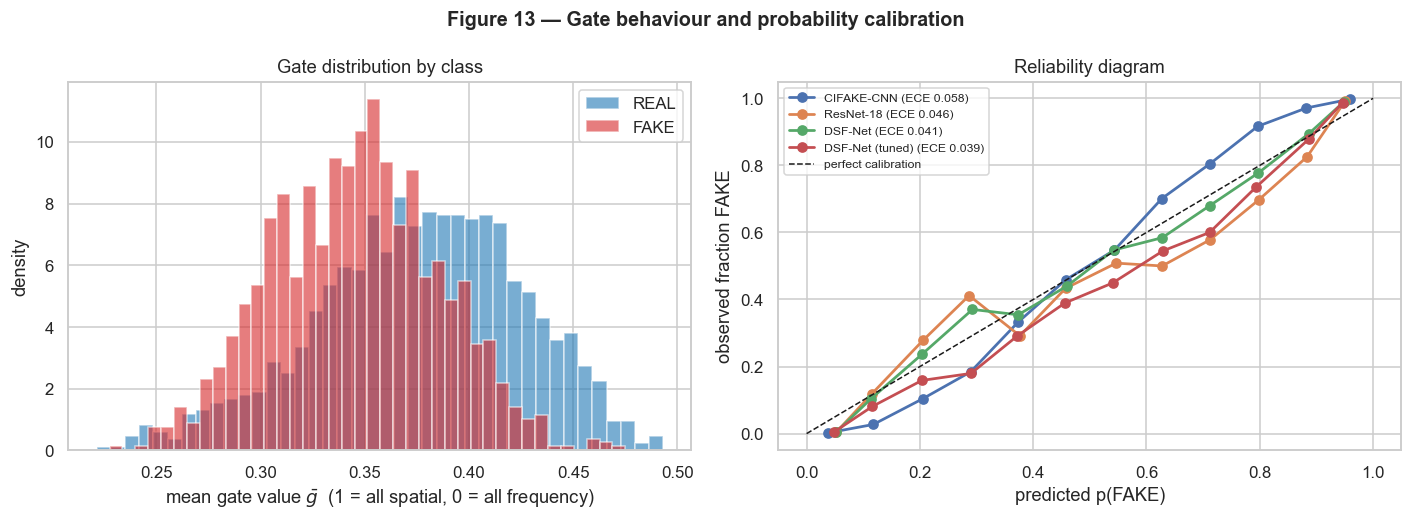

Mean gate on REAL images: 0.3764
Mean gate on FAKE images: 0.3457
A gate that differs between the classes means the network routes the two kinds of
evidence differently — it is not just averaging two opinions with fixed weights.


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for cls, name, colour in [(0, "REAL", "tab:blue"), (1, "FAKE", "tab:red")]:
    axes[0].hist(emb_gates[emb_labels == cls], bins=40, alpha=0.6, color=colour,
                 label=name, density=True)
axes[0].set(xlabel=r"mean gate value $\bar{g}$  (1 = all spatial, 0 = all frequency)",
            ylabel="density", title="Gate distribution by class")
axes[0].legend()

# Reliability diagram for every neural model.
n_bins = 12
edges = np.linspace(0, 1, n_bins + 1)
for name, prob in test_probs.items():
    centres, observed = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (prob >= lo) & (prob < hi)
        if mask.sum() < 30:
            continue
        centres.append(prob[mask].mean())
        observed.append(y_test[mask].mean())
    axes[1].plot(centres, observed, "o-", lw=1.8, ms=6,
                 label=f"{name} (ECE {test_metrics[name]['ece']:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[1].set(xlabel="predicted p(FAKE)", ylabel="observed fraction FAKE",
            title="Reliability diagram")
axes[1].legend(fontsize=8)

fig.suptitle("Figure 13 — Gate behaviour and probability calibration",
             fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("14_gate_and_calibration")
plt.show()

print(f"Mean gate on REAL images: {emb_gates[emb_labels == 0].mean():.4f}")
print(f"Mean gate on FAKE images: {emb_gates[emb_labels == 1].mean():.4f}")
print("A gate that differs between the classes means the network routes the two kinds of")
print("evidence differently — it is not just averaging two opinions with fixed weights.")

## 17. Error analysis

Aggregate metrics hide the interesting failures. Here we look at the cases the model got **confidently
wrong**, in both directions, these are where a deployed system would do real damage.

  saved -> results\figures\15_error_analysis.png


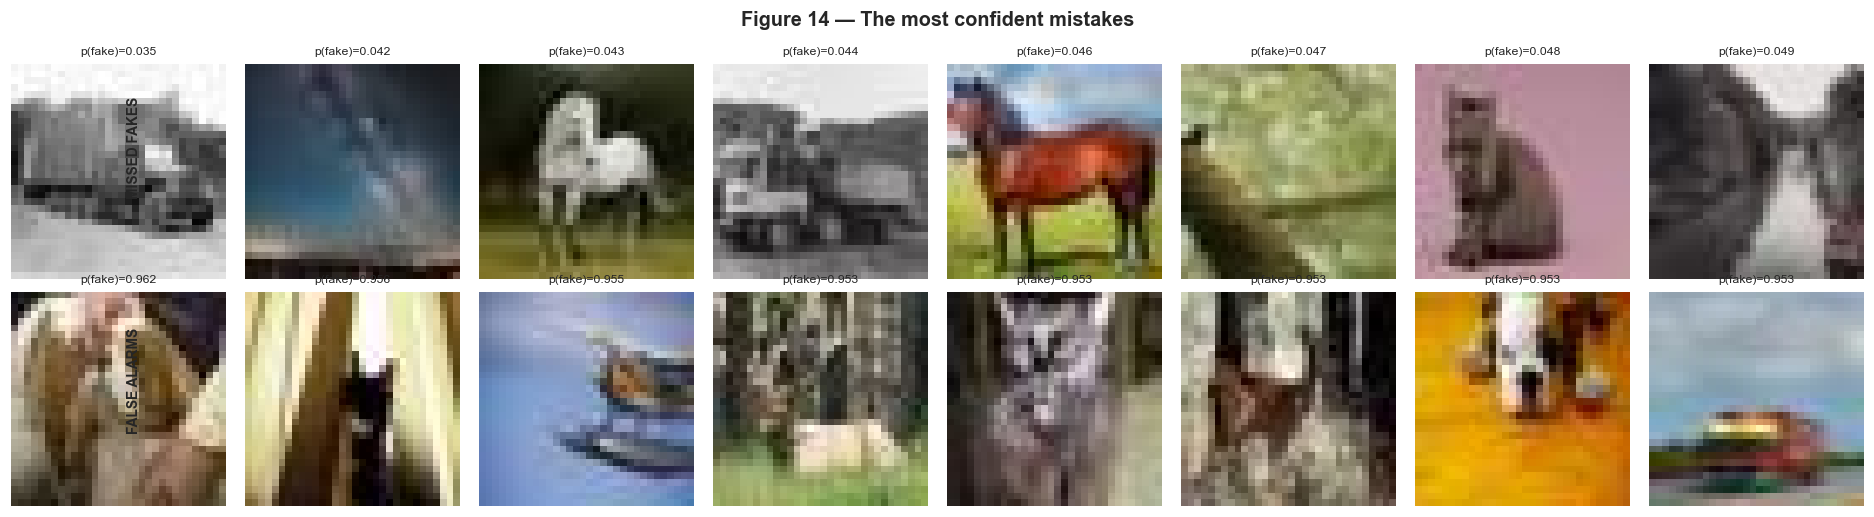

missed fakes (FN): 305  |  false alarms (FP): 552



mean high-frequency detail, correct predictions : 14.195
mean high-frequency detail, incorrect predictions: 14.568


  saved -> results\figures\16_error_vs_detail.png


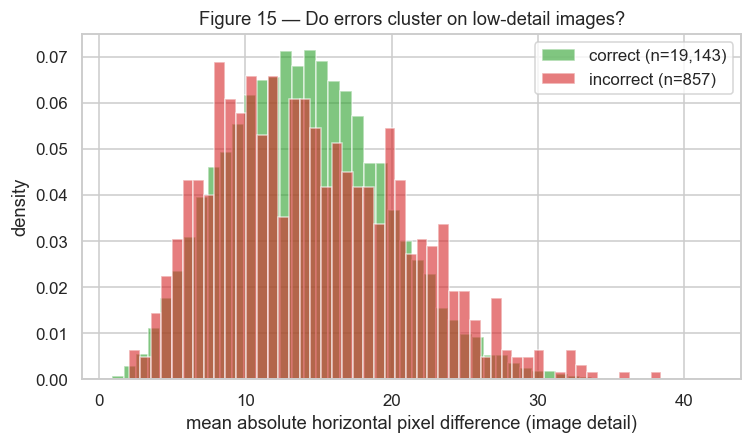

In [49]:
dsf_probs = test_probs["DSF-Net (tuned)"]
false_negatives = np.where((y_test == 1) & (dsf_probs < 0.5))[0]   # fake, called real
false_positives = np.where((y_test == 0) & (dsf_probs >= 0.5))[0]  # real, called fake

worst_fn = false_negatives[np.argsort(dsf_probs[false_negatives])]
worst_fp = false_positives[np.argsort(-dsf_probs[false_positives])]

# A very accurate model may produce fewer than 8 errors of one kind; size the grid to
# whatever actually exists rather than indexing off the end.
n_show = min(8, len(worst_fn), len(worst_fp))

if n_show == 0:
    print("No errors of one or both kinds at threshold 0.5 — nothing to plot here.")
else:
    fig, axes = plt.subplots(2, n_show, figsize=(2.15 * n_show, 4.8), squeeze=False)
    for col in range(n_show):
        axes[0, col].imshow(X_test[worst_fn[col]])
        axes[0, col].set_title(f"p(fake)={dsf_probs[worst_fn[col]]:.3f}", fontsize=8)
        axes[1, col].imshow(X_test[worst_fp[col]])
        axes[1, col].set_title(f"p(fake)={dsf_probs[worst_fp[col]]:.3f}", fontsize=8)
        axes[0, col].axis("off")
        axes[1, col].axis("off")
    fig.text(0.072, 0.72, "MISSED FAKES", rotation=90, va="center", fontweight="bold", fontsize=9)
    fig.text(0.072, 0.28, "FALSE ALARMS", rotation=90, va="center", fontweight="bold", fontsize=9)
    fig.suptitle("Figure 14 — The most confident mistakes", fontweight="bold", fontsize=13)
    plt.tight_layout()
    save_fig("15_error_analysis")
    plt.show()

print(f"missed fakes (FN): {len(false_negatives):,}  |  false alarms (FP): {len(false_positives):,}")

# Are errors concentrated on low-detail images, where there is less fingerprint to read?
# Computed in chunks: the full float32 difference array would be ~500 MB at once.
detail = np.concatenate([
    np.abs(np.diff(X_test[s:s + 4096].astype(np.float32), axis=2)).mean(axis=(1, 2, 3))
    for s in range(0, len(X_test), 4096)
])
correct_mask = ((dsf_probs >= 0.5).astype(int) == y_test)
n_wrong = int((~correct_mask).sum())

print(f"\nmean high-frequency detail, correct predictions : {detail[correct_mask].mean():.3f}")
if n_wrong:
    print(f"mean high-frequency detail, incorrect predictions: {detail[~correct_mask].mean():.3f}")

    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.hist(detail[correct_mask], bins=50, alpha=0.6, density=True,
            label=f"correct (n={correct_mask.sum():,})", color="tab:green")
    ax.hist(detail[~correct_mask], bins=50, alpha=0.6, density=True,
            label=f"incorrect (n={n_wrong:,})", color="tab:red")
    ax.set(xlabel="mean absolute horizontal pixel difference (image detail)", ylabel="density",
           title="Figure 15 — Do errors cluster on low-detail images?")
    ax.legend()
    plt.tight_layout()
    save_fig("16_error_vs_detail")
    plt.show()
else:
    print("No misclassified test images — nothing to compare against.")

## 18. Discussion

### 18.1 Results digest

The cell below regenerates every headline number from the objects in memory, so the report and the
video script can quote figures that are guaranteed to match what actually ran.

In [50]:
digest = []
dsf_name = "DSF-Net (tuned)"
digest.append(f"Test accuracy, {dsf_name}: {comparison.loc[dsf_name, 'accuracy']:.4f}")
digest.append(f"Test ROC-AUC,  {dsf_name}: {comparison.loc[dsf_name, 'roc_auc']:.4f}")
digest.append(f"vs CIFAKE paper (0.9298): {comparison.loc[dsf_name, 'accuracy'] - 0.9298:+.4f}")
digest.append(f"vs ResNet-18 accuracy:   "
              f"{comparison.loc[dsf_name, 'accuracy'] - comparison.loc['ResNet-18', 'accuracy']:+.4f}")
digest.append(f"vs CIFAKE-CNN accuracy:  "
              f"{comparison.loc[dsf_name, 'accuracy'] - comparison.loc['CIFAKE-CNN', 'accuracy']:+.4f}")
digest.append(f"Parameter ratio vs ResNet-18: "
              f"{comparison.loc['ResNet-18', 'params'] / comparison.loc[dsf_name, 'params']:.1f}x smaller")
digest.append(f"Speed ratio vs ResNet-18: "
              f"{comparison.loc[dsf_name, 'img_per_s'] / comparison.loc['ResNet-18', 'img_per_s']:.1f}x faster")
digest.append("")
digest.append(f"Run-to-run noise floor (same config twice): {noise_floor:.2f} pp")
digest.append("")
digest.append("Ablation (test accuracy relative to the full gated model):")
for variant, delta in (ablation_df["test_acc"] - full_acc).items():
    digest.append(f"   {variant:24s} {delta * 100:+6.2f} pp")
digest.append("")
digest.append("Robustness (accuracy drop, clean -> JPEG q30):")
for m, d in sorted(drop.items(), key=lambda kv: -kv[1]):
    digest.append(f"   {m:18s} {d * 100:5.2f} pp")
digest.append("")
digest.append(f"Gate, clean -> JPEG q30: {gates[0]:.4f} -> {gates[-1]:.4f} ({gates[-1] - gates[0]:+.4f})")
digest.append(f"JPEG augmentation: clean {clean_cost * 100:+.2f} pp, JPEG q30 {robust_gain * 100:+.2f} pp")

report_text = "\n".join(digest)
print(report_text)
(RESULTS_DIR / "digest.txt").write_text(report_text, encoding="utf-8")
print(f"\nSaved to {(RESULTS_DIR / 'digest.txt')}")

Test accuracy, DSF-Net (tuned): 0.9571
Test ROC-AUC,  DSF-Net (tuned): 0.9910
vs CIFAKE paper (0.9298): +0.0273
vs ResNet-18 accuracy:   -0.0210
vs CIFAKE-CNN accuracy:  +0.0103
Parameter ratio vs ResNet-18: 13.2x smaller
Speed ratio vs ResNet-18: 2.3x faster

Run-to-run noise floor (same config twice): 0.08 pp

Ablation (test accuracy relative to the full gated model):
   1. spatial only           -0.45 pp
   2. frequency only         -4.35 pp
   3. concat fusion          -0.49 pp
   4. gated fusion (full)    +0.00 pp
   5. no constrained conv    +1.08 pp
   6. no radial features     -0.08 pp
   7. heavy augmentation     +0.91 pp

Robustness (accuracy drop, clean -> JPEG q30):
   frequency only      8.11 pp
   DSF-Net (tuned)     7.33 pp
   spatial only        7.08 pp
   CIFAKE-CNN          5.66 pp
   ResNet-18           5.48 pp

Gate, clean -> JPEG q30: 0.3607 -> 0.3622 (+0.0015)
JPEG augmentation: clean +0.72 pp, JPEG q30 +4.82 pp

Saved to C:\Users\Nihat\Desktop\deep learning final

### 18.2 What the evidence said about each design decision

This project made six substantive claims. The ablation and robustness studies tested them, and the
whole study was then repeated end to end, so each claim can be marked supported, refuted, or
unresolved.

| Claim | Verdict |
|---|---|
| A spectral fingerprint exists and is measurable | **Supported**: Cohen's *d* near 1.0, and a 17-parameter linear model reaches 78.5% |
| The frequency stream adds what the spatial stream lacks | **Weak**: frequency alone is 4.3 pp worse, and adding it is near the noise floor |
| The constrained forensic front-end helps | **Refuted**: removing it gains about 1 pp, in both runs |
| Gated fusion beats concatenation | **Unresolved**: the two runs disagree in sign |
| The gate is readable as a trust signal | **Refuted**, and structurally so, see 18.3 |
| Heavy augmentation destroys the fingerprint | **Refuted**: it helps by about 0.9 pp, in both runs |

The one intervention that clearly worked was JPEG augmentation: +4.8 pp at quality 30 at no cost on
clean images. That variant beats ResNet-18 under heavy compression, the single condition in which
this architecture wins outright.

### 18.3 Why the gate could not have worked

The gate was the point of the architecture, so its failure deserves more than "it did not move".

In the fusion rule

$$ z = g \odot P_s(z_s) + (1 - g) \odot P_f(z_f) $$

the projections $P_s$ and $P_f$ are unconstrained linear maps. The network is free to scale their
weights arbitrarily, so **any** effective weighting between the streams can be realised with **almost
any** value of $g$: a small $g$ paired with a large $\|P_s\|$ is indistinguishable from a large $g$
paired with a small one.

$g$ and the projection norms are therefore **not jointly identifiable**, and $g$ carries no
interpretable meaning on its own. The measured mean gate of about 0.36 would naively imply the model
draws two thirds of its decision from the frequency stream, which the ablation shows is impossible,
since that stream alone is 4.3 points worse and removing it costs almost nothing.

The interpretability claim was untestable as built, not merely unsupported. The repair is concrete:
weight-normalise $P_s$ and $P_f$, or apply the gate after LayerNorm on both branches, so that $g$
carries the entire scaling. Only then does reading $g$ mean anything.

### 18.4 Challenges encountered

**A silent float32 accumulation bug.** The first full run reported channel means of
`[0.182, 0.182, 0.182]`. Three identical channel means are impossible for real RGB data, and that was
the tell. Summing 92 million float32 values sequentially saturates: once the running total passes
about 4e7, the gap between representable float32 values is 4.0, so adding another 0.45 does nothing.
The correct means are `[0.472, 0.463, 0.418]`.

Every model had therefore been trained with the wrong normalisation constants. The fix was to
accumulate in float64 and to add a guard that cross-checks the full-set statistics against a
2,000-image probe too small to saturate. Rather than assume the effect was harmless, the entire study
was re-run: every model moved by less than the noise floor, because the wrong normalisation was a
*consistent affine transform* that networks with BatchNorm absorb easily. The spectral baselines came
out bit-identical, since they never touch the normalisation, confirming the fix landed in the right
place.

**The signal is invisible, so debugging is hard.** A human cannot look at a 32x32 image and check the
label, so a broken model and a hard problem look identical. The mitigation was to build the spectral
difference figure *before* the model: once it showed structure, any failure to reach that signal was
our bug. `tools/smoke_test.py` plays the same role for the code by planting a known artefact in
synthetic data, and `tools/pipeline_test.py` executes every cell in minutes.

**A Unicode crash on Windows.** Degradation labels containing Greek letters could not be encoded by a
cp1252 console and killed a run mid-way. Fixed by forcing UTF-8 on stdout/stderr and using ASCII
labels.

**Mixed precision and the FFT.** `fft2` under autocast produces half-precision complex tensors, which
are unsupported or unstable depending on the build. The frequency stream forces fp32 around the
transform only.

**The constrained convolution is not differentiable.** Enforced by projection after every optimiser
step, which required a hook in the training loop rather than a change to the model.

### 18.5 Limitations

1. **The architecture is not novel in its parts.** Two-stream spatial-frequency fusion, radial
   spectral features and gated injection are all established in the literature. This is a specific
   combination, and the ablation shows it adds little over its spatial component alone.
2. **One generator, one resolution.** Every fake image is Stable Diffusion v1.4 at 32x32. Nothing here
   predicts performance on Midjourney, FLUX, or a 2026 model. Cross-generator generalisation is the
   central open problem in this field and is untested here.
3. **Two runs is not a variance estimate.** It is enough to detect non-replication, which is what we
   used it for, but not to put error bars on anything. Five or more seeds per variant would be needed.
4. **The gate is not identifiable** (18.3), so no interpretability claim can rest on it as built.
5. **Robustness is worse than the baselines**, not better. DSF-Net leans harder on high frequencies,
   and every degradation tested attacks high frequencies.
6. **No adversarial evaluation.**
7. **Content shift is confounded with generator shift.** CIFAKE's real images come from CIFAR-10, so
   the classes differ slightly in content distribution as well as in origin.

### 18.6 Future work

* **Make the gate identifiable**: weight-normalise the projections, then re-test the interpretability
  claim properly. This is the direct repair of 18.3.
* **Use the gate for selective prediction**: if it becomes meaningful, test whether it predicts unseen
  generators and supports calibrated abstention. That is a function, not another fusion variant.
* **Multi-generator training** with leave-one-generator-out evaluation on GenImage or AI-GenBench.
* **Higher resolution with patch-based inference**, where far more fingerprint is available.
* **Replace the constrained front-end**: which the ablation shows is harmful, with a learnable
  high-pass regularised *toward* the residual constraint rather than pinned to it.
* **Compare against vision-foundation-model (CLIP) features**, the current strong line of work, which
  none of our baselines cover.

## 19. Conclusion

We designed, implemented and evaluated **DSF-Net**, a compact dual-stream architecture for detecting
AI-generated images, following an observation about the data rather than architectural fashion: the
discriminative signal here is spectral, not semantic.

On the numbers, the project delivers a competent detector: **95.71% test accuracy**, **2.73 points
above the published CIFAKE reference**, at **13.2x fewer parameters** and **2.3x the throughput** of a
fine-tuned ResNet-18, with the best calibration of any model tested. Its JPEG-augmented variant beats
ResNet-18 under heavy compression.

On the hypotheses, most of the design did not survive contact with evidence. The constrained forensic
front-end hurts. Heavy augmentation, predicted to be harmful, helps. The gate does not move under
degradation, and a structural analysis shows it never could have. The central claim that gating beats
concatenation did not replicate across two independent full runs.

The most valuable output of this project is that last sentence. Running the whole study a second time
cost ninety minutes and converted a plausible-looking half-point improvement into a demonstrated
non-result. A single run would have reported the opposite with equal confidence and equally
clean-looking evidence, and nothing in the table would have revealed which one it was.

## References

1. Bird, J. J., & Lotfi, A. (2024). *CIFAKE: Image Classification and Explainable Identification of
   AI-Generated Synthetic Images.* IEEE Access, 12, 15642-15650. arXiv:2303.14126
2. Wang, S.-Y., Wang, O., Zhang, R., Owens, A., & Efros, A. A. (2020). *CNN-generated images are
   surprisingly easy to spot... for now.* CVPR.
3. Frank, J., Eisenhofer, T., Schönherr, L., Fischer, A., Kolossa, D., & Holz, T. (2020). *Leveraging
   Frequency Analysis for Deep Fake Image Recognition.* ICML.
4. Bayar, B., & Stamm, M. C. (2018). *Constrained Convolutional Neural Networks: A New Approach Towards
   General Purpose Image Manipulation Detection.* IEEE TIFS, 13(11), 2691-2706.
5. Zhu, M., et al. (2023). *GenImage: A Million-Scale Benchmark for Detecting AI-Generated Image.*
   NeurIPS Datasets and Benchmarks.
6. Selvaraju, R. R., et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via
   Gradient-based Localization.* ICCV.
7. Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). *On Calibration of Modern Neural
   Networks.* ICML.
8. Loshchilov, I., & Hutter, F. (2019). *Decoupled Weight Decay Regularization.* ICLR.
9. Rombach, R., Blattmann, A., Lorenz, D., Esser, P., & Ommer, B. (2022). *High-Resolution Image
   Synthesis with Latent Diffusion Models.* CVPR. (Stable Diffusion, the generator behind CIFAKE's
   fake images.)